In [1]:
# Instalamos qiskit en el notebook
!pip install qiskit[visualization] qiskit-ibm-runtime qiskit_machine_learning

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# importing Qiskit
from qiskit import QuantumCircuit, QuantumRegister, transpile
from qiskit.quantum_info import Statevector


# **Introducción al Quantum Machine Learning (QML)**

### Contenidos

1. [Introducción](#intro)
1. [Codificacion de la información](#info)
1. [Máquinas de soporte vectorial cuánticas (QSVMs)](#qsvm)
1. [Redes neuronales cuánticas (QNNs)](#qnn)
1. [QNNs en Qiskit](#qnnqiskit)
1. [Otras librerías para QML](#otros)

Ejercicios

1. [Ejercicio entregable 9: dataset de círculos concéntricos](#e9)
1. [Ejercicio entregable 10: Quantum Feedforward Neural Network simple](#e10)
1. [Ejercicio entregable 11: red con data reuploading](#e10)


<a name="intro"></a>
# **Introducción**

Diferentes enfoques según el tipo de datos y como se procesan:

<center><img src="https://drive.google.com/uc?export=view&id=1nIrVTAzMzylSa7PXyxAm2TgN6R9BdClG" alt="Aproximaciones a QML" width="500"  /></center>

El término Quantum Machine Learning (QML) se usa a menudo para referirse al caso CQ: uso de algoritmos cuánticos para acelerar la ejecución de problemas de ML con datos clásicos.


Algunos ejemplos de uso de QC en el campo del ML son:

1. Quantum Support Vector Machines (QSVM)
2. Quantum Neural Networks (QNNs)
1. Quantum Reinforcement Learning (QRL)
3. Quantum Boltzmann Machines (QBM)
4. Quantum Principal Component Analysis (QPCA)
5. ...



**Pasos para realizar la computación del modelo en un sistema cuántico**

Ejemplo con un clasificador:

1. Codificamos los datos (features) en estados cuánticos
2. Aplicamos un circuito variacional usando un conjunto de parámetros
3. Medir un cierto observable y determinamos la clasificación en función de los resultados
4. Optimizamos los parámetros con un optimizador clásico

<center><img src="https://drive.google.com/uc?export=view&id=15DbNGFMLC1qmLMHyjlPoE9y12K7HI3Ew" alt="VQC" width="800"  /></center>


Nota: varias de las imágenes de este notebook están extraidas del curso [Qiskit Global Summer School 2021](https://www.youtube.com/playlist?list=PLOFEBzvs-VvqJwybFxkTiDzhf5E11p8BI)

<a name="info"></a>
# **Codificación de la información**

Codificar nuestros datos como un estado cuántico: diferentes soluciones propuestas

  - Problema abierto y bajo estudio
  - Dependiente del problema concreto

## Codificación en la base (Basis encoding)

La codificación más simple es usar los cúbits como bits clásicos. Así, por ejemplo, si tenemos 8 cúbits el valor $123$ se representaría como el estado $|01111011\rangle$

También se pueden agrupar los cúbits en _registros_, cada uno con un estado especificando un valor:

$$
\begin{bmatrix}
7\\11
\end{bmatrix} = |0111\rangle|1011\rangle
$$

- Ventajas: el estado es fácil de preparar
- Inconvenientes: necesitamos muchos cúbits

## Codificación en superposición

Alternativamente, un vector de hasta $2^n$ enteros puede ser codificado en estados en superposición de $n$ cúbits.

Por ejemplo con 3 cúbits:

$$
\begin{bmatrix}
1\\3\\5\\6
\end{bmatrix} =
\frac{1}{2}(|001\rangle+|011\rangle + |101\rangle + |110\rangle)
$$

 - Ventajas: se pueden hacer operaciones que afectan a todos los elementos del vector simultáneamente.
 - Inconvenientes: la codificación no puede realizarse de forma eficiente

Ejemplo: prepara el vector $[1,3,5,6]^T$

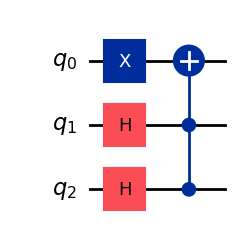

<IPython.core.display.Latex object>

In [3]:
q = QuantumRegister(3, name='q')
qc = QuantumCircuit(q)

## Iniciamos el estado
qc.x(q[0])
qc.h(q[1])
qc.h(q[2])
qc.ccx(q[2],q[1],q[0])

display(qc.draw('mpl'))

# Mostramos el vector de estado
estado = Statevector.from_circuit(qc)
estado.draw('latex')

## Codificación en amplitud

Un vector de $2^n$ elementos puede ser codificado en las amplitudes de $n$ cúbits.

Ventajas:

1. Permite almacenar hasta $N = 2^n$ amplitudes en $n$ cúbits

Inconvenientes:

1. El número de elementos del vector debe ser potencia de 2: necesario aplicar *padding*
1. El vector debe estar normalizado
1. El proceso de codificación no es trivial
  - El número de puertas CNOT crece con el número de elementos del vector $\mathcal{O}(N)$ $⇒$ es exponencial en el nº de cúbits $\mathcal{O}(2^n)$

Uso práctico: necesidad de [QRAM](https://en.wikipedia.org/wiki/Quantum_memory) que permita cargar datos clásicos en registros cuánticos (no existe todavía).

**Ejemplo**: inicialización de un vector de $2^n$ elementos en un sistema fake de IBMQ:

In [4]:
n = 5
# Creamos un vector aleatorio de 2**n elementos
v = np.random.random(2**n)
print(v)

[0.82610531 0.60988442 0.51498354 0.13652501 0.75893093 0.47117949
 0.04212281 0.15240626 0.02703896 0.11284541 0.39296505 0.6998612
 0.62673705 0.96464632 0.49169714 0.61164849 0.92355414 0.35177678
 0.6754329  0.30028812 0.71338545 0.96635191 0.87546881 0.77098693
 0.69395743 0.27536251 0.20533811 0.83044313 0.90846714 0.30066696
 0.00774793 0.51036819]


In [5]:
# Normalizamos v
vnorm = v / np.linalg.norm(v)
print(np.linalg.norm(vnorm))
print(vnorm)

1.0
[0.24307403 0.17945299 0.15152926 0.04017125 0.22330858 0.13864031
 0.01239426 0.04484417 0.00795597 0.03320374 0.11562642 0.20592784
 0.18441172 0.28383848 0.14467745 0.17997205 0.27174747 0.10350714
 0.19874004 0.08835707 0.20990723 0.28434033 0.2575988  0.22685595
 0.20419071 0.08102293 0.06041888 0.2443504  0.26730826 0.08846854
 0.00227976 0.15017124]


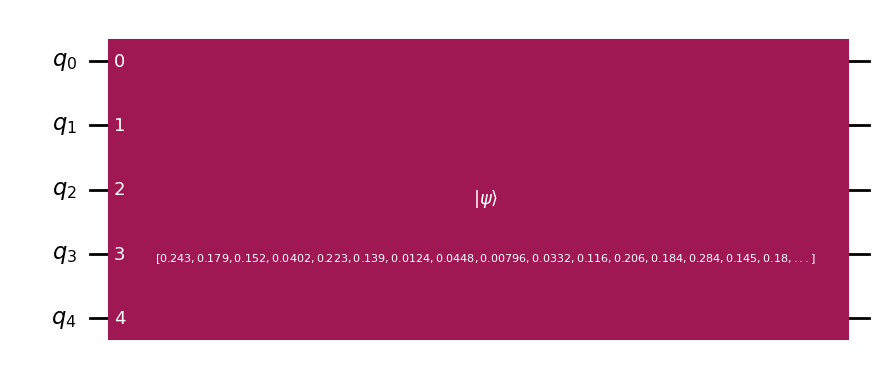

<IPython.core.display.Latex object>

In [6]:
# Iniciamos un circuito de n cúbits al vector normalizado
qc = QuantumCircuit(n)
qc.initialize(vnorm)
display(qc.draw('mpl'))
# Mostramos el vector de estado
estado = Statevector.from_circuit(qc)
estado.draw('latex')

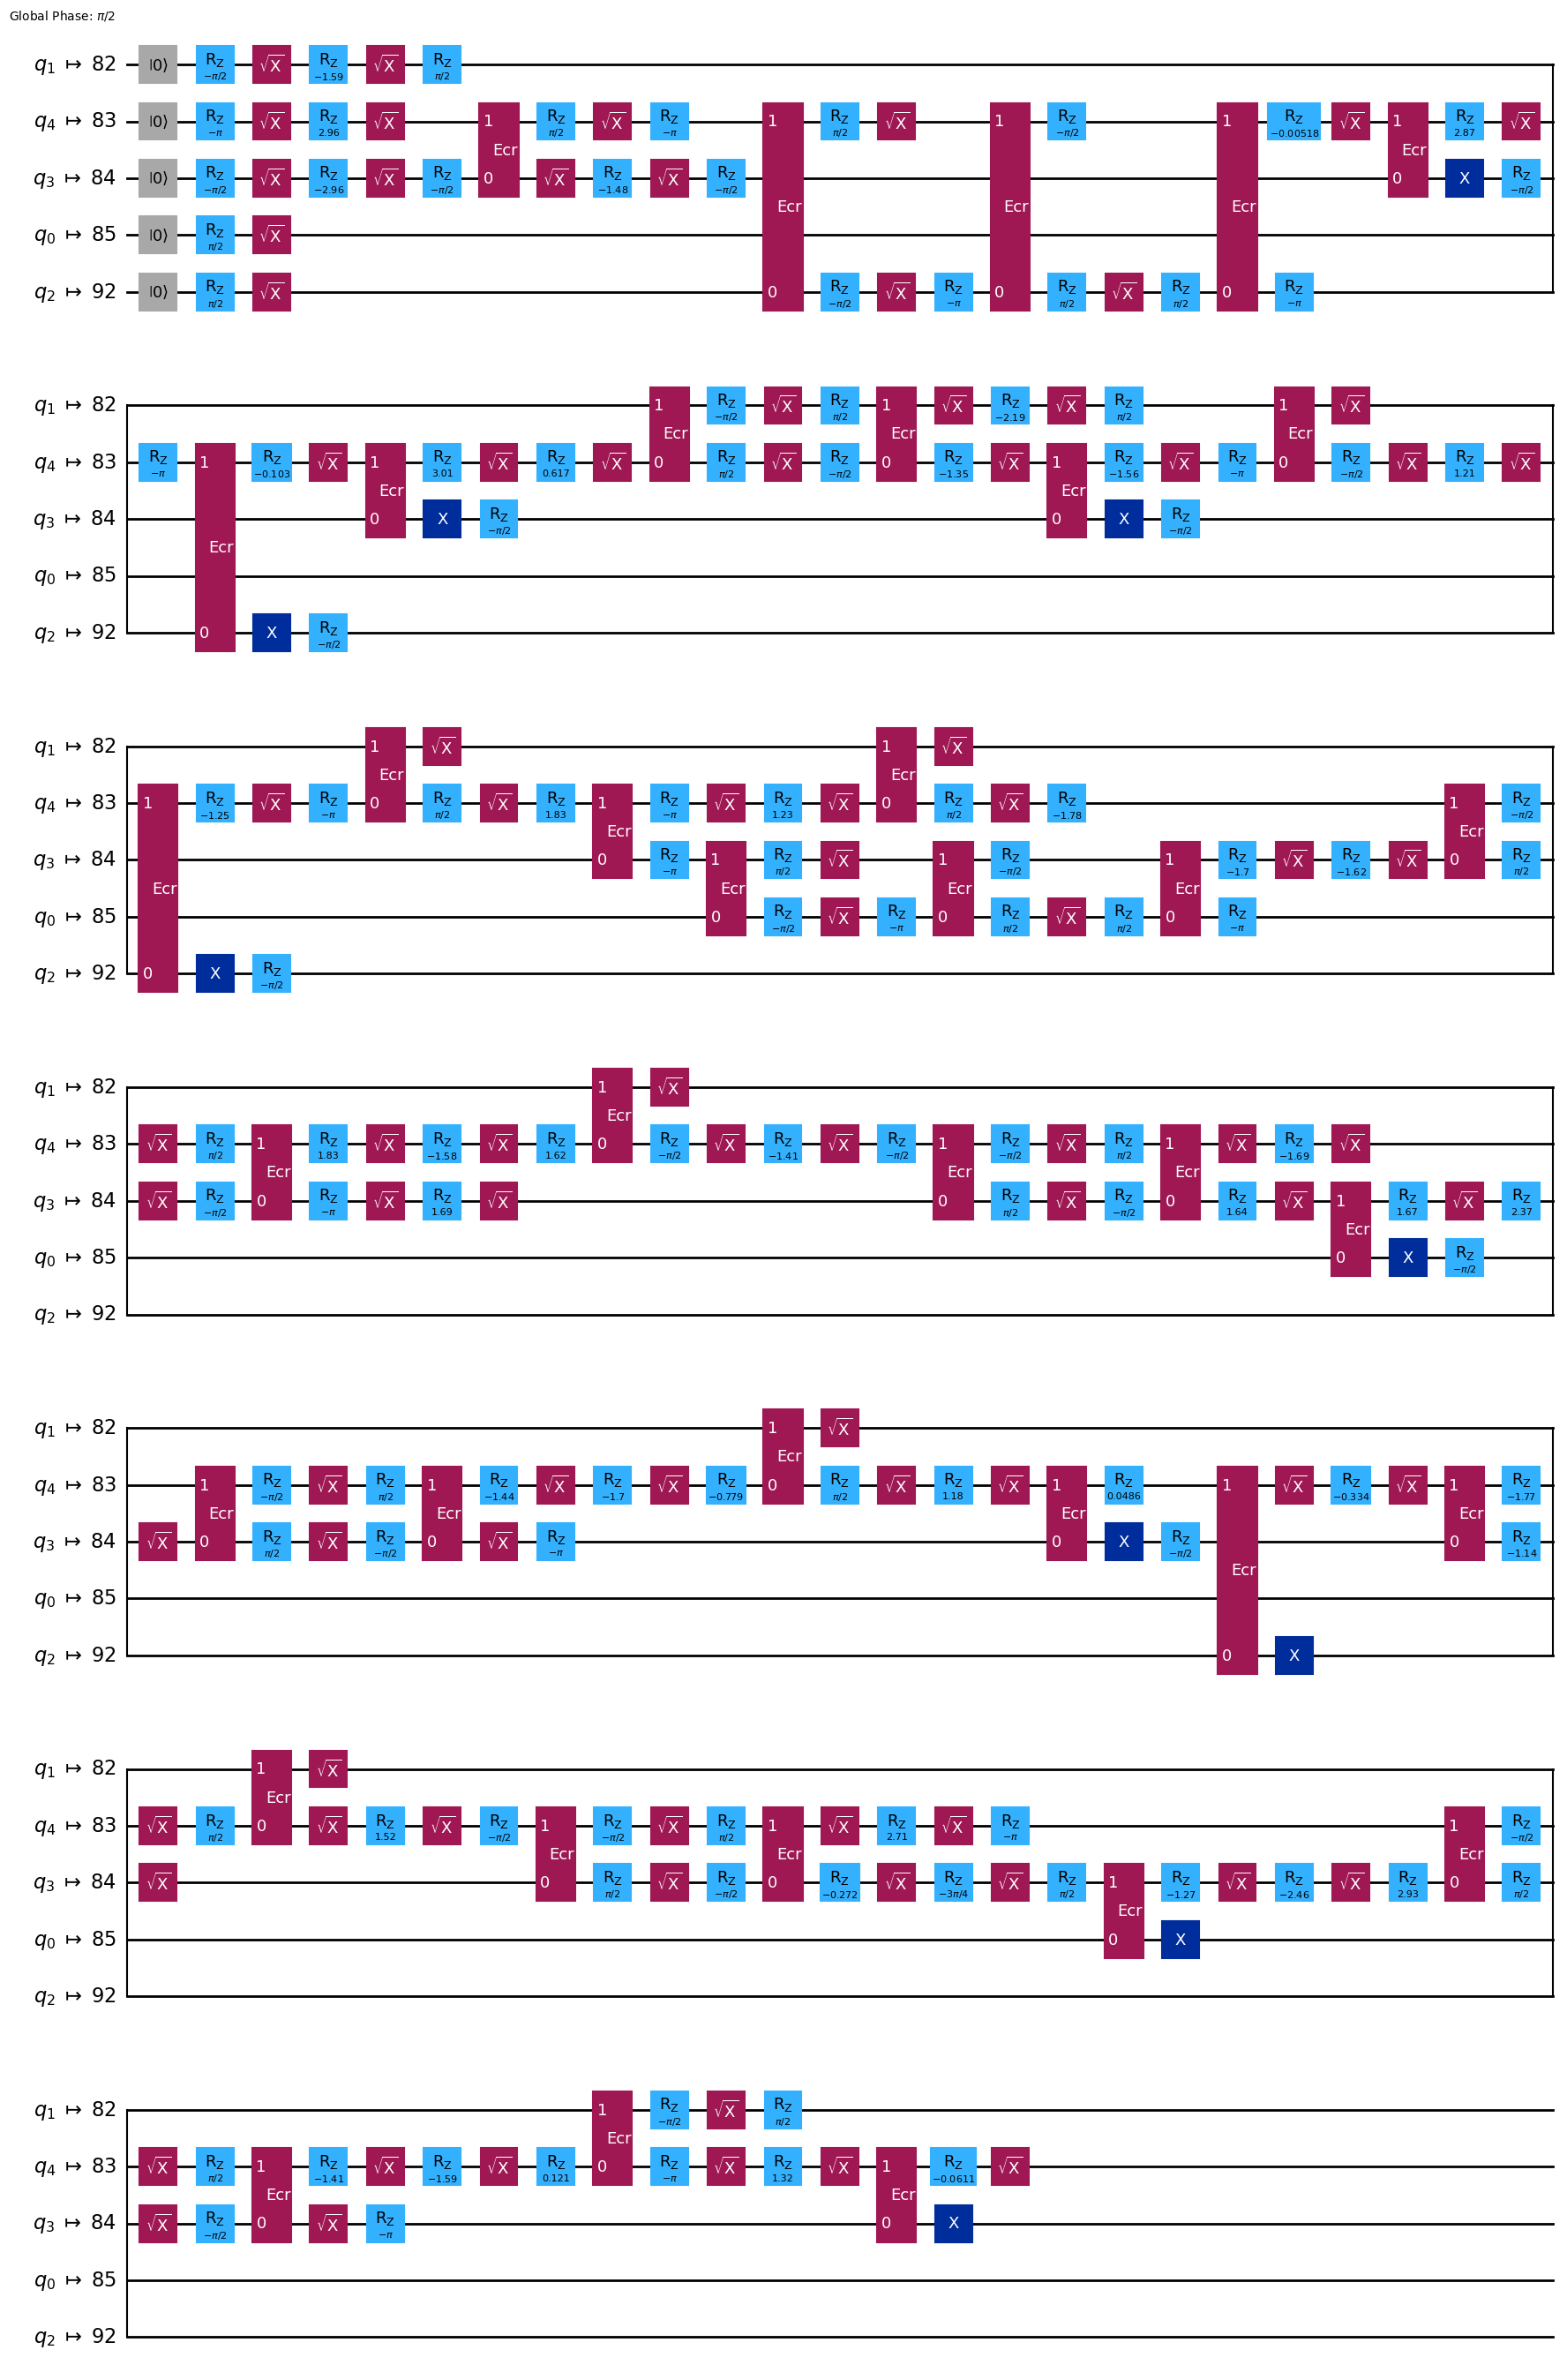

In [7]:
# Traspilamos a un FakeProvider
from qiskit_ibm_runtime.fake_provider import FakeOsaka

fake_backend = FakeOsaka()

# Creamos el Pass manager para ese backend
qc_transpilado = transpile(qc, fake_backend)


qc_transpilado.draw("mpl", idle_wires=False)

## Codificación en ángulos (Angle encoding)

Aplicamos a cada cúbit una rotación con un ángulo igual al valor a codificar

  - Necesitamos tantos cúbits como valores a codificar
  - Valores normalizados al intervalo $[-\pi,\pi]$ o $[0, 2\pi]$
  - Codifica un vector de $n$ componentes en un estado de dimensión $2^n$
  - Fácil implementación: usualmente puertas $R_y$

  $$
R_y(x) =
\begin{bmatrix}
\cos\frac{x}{2}   & -\sin\frac{x}{2}\\
\sin\frac{x}{2} & \cos\frac{x}{2}
\end{bmatrix}
$$

$$
R_y(x)|0\rangle = \cos\frac{x}{2}|0\rangle + \sin\frac{x}{2}|1\rangle
$$

Vector a codificar [0.20017526 0.7456649  0.09296785 0.47311061]


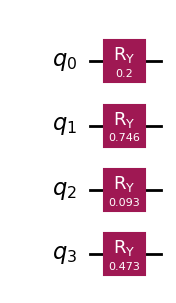

<IPython.core.display.Latex object>

In [8]:
n = 4 # Número de cúbits

v = np.random.random(n) # Datos entre 0 y 1
print(f'Vector a codificar {v}')

qc = QuantumCircuit(n)
for q in range(n):
    qc.ry(v[q], q)

display(qc.draw('mpl'))

# Mostramos el vector de estado
estado = Statevector.from_circuit(qc)
estado.draw('latex')

## Codificación en la fase (Phase encoding)

Similar al *angle encoding* pero usando puertas _phase shift_ que cambian la fase relativa:

$$
P_\theta  = \begin{bmatrix}1 & 0 \\ 0 & e^{i\theta} \end{bmatrix}
$$

Como $P_\theta|0\rangle = |0\rangle$ necesitamos usar una puerta $H$ antes de la $P_\theta$:

$$
P_x|+\rangle = \frac{1}{\sqrt{2}}(|0\rangle + e^{ix}|1\rangle)
$$

## Dense angle encoding

Es una combinación de angle y phase encoding.

 - Usamos primero una $R_y$ y luego una $P$ con diferentes valores
 - Permite codificar $2n$ valores usando solo $n$ cúbits


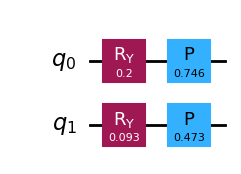

<IPython.core.display.Latex object>

In [9]:
qc = QuantumCircuit(n/2)
for q in range(0,n,2):
    qc.ry(v[q], q//2)
    qc.p(v[q+1],q//2)

display(qc.draw('mpl'))

# Mostramos el vector de estado
estado = Statevector.from_circuit(qc)
estado.draw('latex')

## _Higher order encoding_

Incluyen diferentes rotaciones y entrelazamiento entre los cúbits.

**Ejemplo**: [`EfficientSU2`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.EfficientSU2)



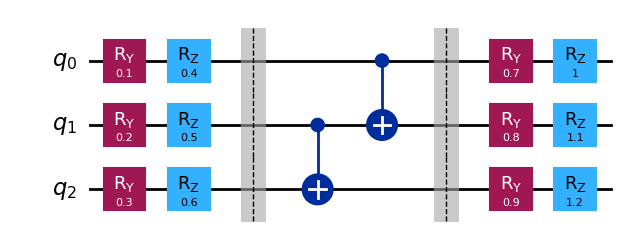

In [10]:
from qiskit.circuit.library import efficient_su2
# Codificamos un vector de 12 características en 3 cúbits
x = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0, 1.1, 1.2]
circuit = efficient_su2(num_qubits=3, reps=1, insert_barriers=True)
encode = circuit.assign_parameters(x)
encode.draw(output="mpl")

Estamos codificando los 12 elementos del vector en los 8 números complejos del estado $|\psi\rangle = c_0|000\rangle + \ldots + c_7|111\rangle$

Otras codificaciones de alto nivel son el [`ZFeatureMap`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.z_feature_map) y el [`ZZFeatureMap`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.zz_feature_map), que veremos más adelante.



---



---



---



<a name="qsvm"></a>
# **Máquinas de soporte vectorial cuánticas (QSVMs)**

<center><img src="https://drive.google.com/uc?export=view&id=15Z8lqGOIpDCiAfUZRqMumMOXu-wAqcQM" alt="SVM clásico" width="800"  /></center>


## [Kernel trick](https://en.wikipedia.org/wiki/Kernel_trick)

Se usa una transformación no lineal (_feature map_) $\varphi(\mathbf{x})$ para mapear los datos desde el espacio
original a un nuevo espacio de más dimensiones (espacio de características) donde la superficie de decisión (hiperplano) se vuelva lineal.

El hiperplano en este espacio se puede escribir como:

$$\omega^T\varphi(\mathbf{x}) +b =0$$

y la función de clasificación:

$$y = \mathrm{label}(\mathbf{x}) = \mathrm{sign}(\omega^T\varphi(\mathbf{x}) +b)$$


### Forma dual

En vez de calcular el hiperplano, la denominada *forma dual* permite expresar en problema como una maximización de los _multiplicadores de Lagrange_ $\alpha_i$:

$$
\max_\alpha C_D(\alpha) = \sum_{i\in T} \alpha_i - \frac{1}{2}\sum_{i,j\in T} y_i y_j\alpha_i\alpha_j\langle\varphi(\mathbf{x_i})|\varphi(\mathbf{x_j})\rangle
$$
donde $T$ es el conjunto de entrenamiento y los valores $\alpha_i\ge 0$ solo son no-nulos para los vectores soporte en $T$.

La función de clasificación se puede escribir ahora como:

$$\mathrm{label}(\mathbf{s}) = \mathrm{sign}\left(\sum_{i\in V}\alpha_iy_iK(\mathbf{s},\mathbf{x_i}) +b\right)$$

donde $V$ es el conjunto de vectores soporte, $K$ la _función kernel_:

$$
K(\mathbf{x_i},\mathbf{x_j}) = K_{ij} = \langle\varphi(\mathbf{x_i})|\varphi(\mathbf{x_j})\rangle
$$

y $b$ se obtiene a partir de cualquier vector de soporte $x_k$:

$$
b = y_k - \sum_{i\in T} \alpha_i y_i K(\mathbf{x_i}, \mathbf{x_k})
$$


Los valores de la función (o matrix) kernel $K$ proporcionan una medida de _similaridad_ entre puntos en el espacio de características.

Esta matriz puede obtenerse sin necesidad de computar los productos internos $\langle\varphi(\mathbf{x_i})|\varphi(\mathbf{x_j})\rangle$ a través de funciones que codifiquen de forma implícita el feature map.

Ejemplo: [Radial Basis Function Kernel](https://en.wikipedia.org/wiki/Radial_basis_function_kernel)

$$
K(\mathbf{x_i},\mathbf{x_j}) = \exp\left(-\frac{\lVert \mathbf{x_i}-\mathbf{x_j}\rVert^2}{2\sigma²}\right)
$$

## SVMs cuánticas

Existen dos propuestas principales de SVMs cuánticas: los *clasificadores variacionales cuánticos* (VQC) y los *estimadores de kernel cuánticos* (QKE)



### Variational Quantum Classifier (VQC)

<center><img src="https://drive.google.com/uc?export=view&id=10kCs4HAuz-5oEisufPGajVtzPMysnTpB" alt="Variational Quantum Classifier (VQC)" width="500"  /></center>

Se trata de un clasificador lineal dentro de un espacio de características de alta dimensión.

Bloques:

  - El primer circuito define el *feature map*: $\varphi(\mathbf{x}) = \Phi(\mathbf{x})|0\rangle$
  - $W_\theta$ es un circuito variacional parametrizado por los valores $\theta$ y determina el hiperplano de separación.

La salida del circuito es el estado:

$$
|\Psi\rangle = W_\theta\Phi(x) |0\rangle
$$


Midiendo el valor esperado del observable Z obtenemos el clasificador:

$$
f_\theta(x) = \langle\Psi|Z|\Psi\rangle = \langle 0|\Phi^\dagger(x)W^\dagger_\theta ZW_\theta\Phi(x)|0\rangle \in [-1,1]
$$

Para la función de clasificación se elige un umbral $b\in [-1,1]$ y se define:

$$
\text{label}(x) =  \left\lbrace
\begin{array}{ll}
+1 & \text{si } f_\theta(x) \ge b\\
-1 & \text{si } f_\theta(x) < b
\end{array}
\right.
$$

Se puede demostrar que este modelo es un clasificador lineal en el espacio de características $\Phi(x)$ y $W_\theta$ parametriza el hiperplano.

Limitación: $W_\theta$ limitado por la profundidad del circuito $\Rightarrow$ no se puede probar con todos los hiperplanos posibles $\Rightarrow$ es posible que no se encuentre la solución óptima.



### Quantum Kernel Estimator (QKE)

Usa el computador cuántico solo para estimar la matriz kernel $K$.

<center><img src="https://drive.google.com/uc?export=view&id=1naiNKfs5wrUw65xwvJf4EOA4qUDM_r36" alt="Quantum Kernel Estimator (QKE)" width="450"  /></center>

De nuevo, se define el *feature map* como: $\varphi(\mathbf{x}) = \Phi(\mathbf{x})|0\rangle$



La salida del circuito para un par de vectores de características $\mathbf{x_i}$ y $\mathbf{x_j}$ es:

$$
|\Psi\rangle = \Phi(\mathbf{x_j})^\dagger\Phi(\mathbf{x_i})|0\rangle
$$

La regla de Born nos dice que la probabilidad de obtener el estado $|0\rangle$ a la salida es:

$$
\text{Pr}(|0\rangle) = |\langle0|\Psi\rangle|^2 = |\langle0|\Phi(\mathbf{x_j})^\dagger\Phi(\mathbf{x_i})|0\rangle|^2 = |\langle\varphi(\mathbf{x_j})|\varphi(\mathbf{x_i})\rangle|^2
$$

Obtenemos la matriz kernel cuántica (_quantum kernel_) midiendo la probabilidad de obtener el estado $|0\rangle$ a la salida del circuito:

$$
K_{i,j} = |\langle\varphi(\mathbf{x_j})|\varphi(\mathbf{x_i})\rangle|^2 = |\langle0|\Phi(\mathbf{x_j})^\dagger\Phi(\mathbf{x_i})|0\rangle|^2
$$

En este caso, los valores de $K$ proporcionan una medida de solapamiento (_overlap_) entre los estados $|\varphi(\mathbf{x_i})\rangle$ y $|\varphi(\mathbf{x_j})\rangle$. Este solapamiento se denomina **fidelidad**:
  - Si los estados $|\varphi(\mathbf{x_i})\rangle|$ y $|\varphi(\mathbf{x_j})\rangle|$ son idénticos, la fidelidad es 1.
  - Si los estados $|\varphi(\mathbf{x_i})\rangle|$ y $|\varphi(\mathbf{x_j})\rangle|$ son ortogonales, la fidelidad es 0.

Se ha demostrado que QKE solo proporciona ventaja frente a un sistema clásico si $\varphi(\mathbf{x})$ es suficientemente compleja y difícil de simular clásicamente.

## *Feature maps* cuánticos

Un _feature map_ cuántico codifica los datos clásicos como estados cuánticos:

  - Cualquier mecanismo de encoding (p.e. angle o fase encoding) puede usarse como _feature map_


Datos normalizados: [0.         2.0943951  4.1887902  6.28318531]


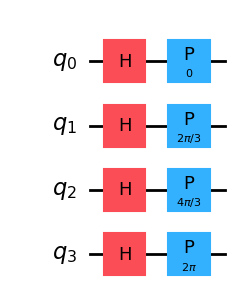

<IPython.core.display.Latex object>

In [11]:
from qiskit.circuit import ParameterVector

# Codificar un vector de 4 características usando phase encoding
datos = np.array([10., 20., 30., 40.])

# Normalizamos para tener los datos entre 0 y 2π
datos_norm = 2*np.pi*((datos - datos.min()) / (datos.max() - datos.min()))

print(f"Datos normalizados: {datos_norm}")

# creamos un circuito paramétrico con 1 cubit por dato
# Numero de cubits
n = len(datos)

# Definimos el vector de parámetros y el circuito parametrizado
parameters = ParameterVector('θ', n)
circuit = QuantumCircuit(n)
for i in range(n):
    circuit.h(i)
    circuit.p(parameters[i], i)

# Asigno valores a los parámetros
circuit_p = circuit.assign_parameters(parameters = datos_norm)
display(circuit_p.draw('mpl'))

# Estado de salida
estado = Statevector.from_circuit(circuit_p)
estado.draw('latex')


Codifico un vector de cuatro elementos como un nuevo vector de dimensión 16.

Importante:
  - Suele ser mejor trabajar con datos normalizados en el rango $[0,1]$ 0 $[-1,1]$ (evitando llegar a $2\pi$) para tener modelos menos sensibles a errores en los datos de entrada.

Qiskit tiene implementados algunos *feature maps* cuánticos. Uno de ellos, [`ZFeatureMap`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.z_feature_map) es un simple phase encoding como el que acabamos de usar (con 2 repeticiones, por defecto):

Datos normalizados: [0.         1.04719755 2.0943951  3.14159265]


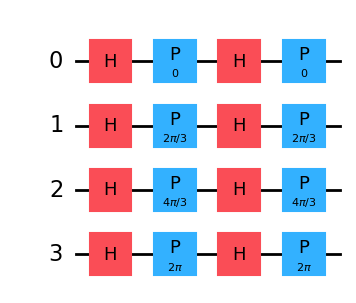

<IPython.core.display.Latex object>

In [12]:
from qiskit.circuit.library import z_feature_map

# En este caso, las rotaciones tienen que estar entre 0 y π
# ya que multiplica el ángulo por 2
datos_norm = np.pi*((datos - datos.min()) / (datos.max() - datos.min()))

print(f"Datos normalizados: {datos_norm}")

# El número de repeticiones se puede cambiar con el parámetro reps
map_z = z_feature_map(feature_dimension=4)
map_z.draw('mpl')

circuit_p = map_z.assign_parameters(parameters = datos_norm)
display(circuit_p.draw('mpl'))

estado = Statevector.from_circuit(circuit_p)
estado.draw('latex')

Otros *feature maps* más complejos son:
  
  - [`ZZFeatureMap`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.zz_feature_map): phase encoding con puertas $R_{ZZ}(\theta)$ que entrelazan los cúbits para intentar codificar correlaciones entre las características de los datos clásicos
  - [`PauliFeatureMap`](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.pauli_feature_map): permite especificar otros tipos de rotaciones, no solo en Z.
  
En concreto, el ZZFeatureMap esta considerado como difícil de simular en un sistema clásico.

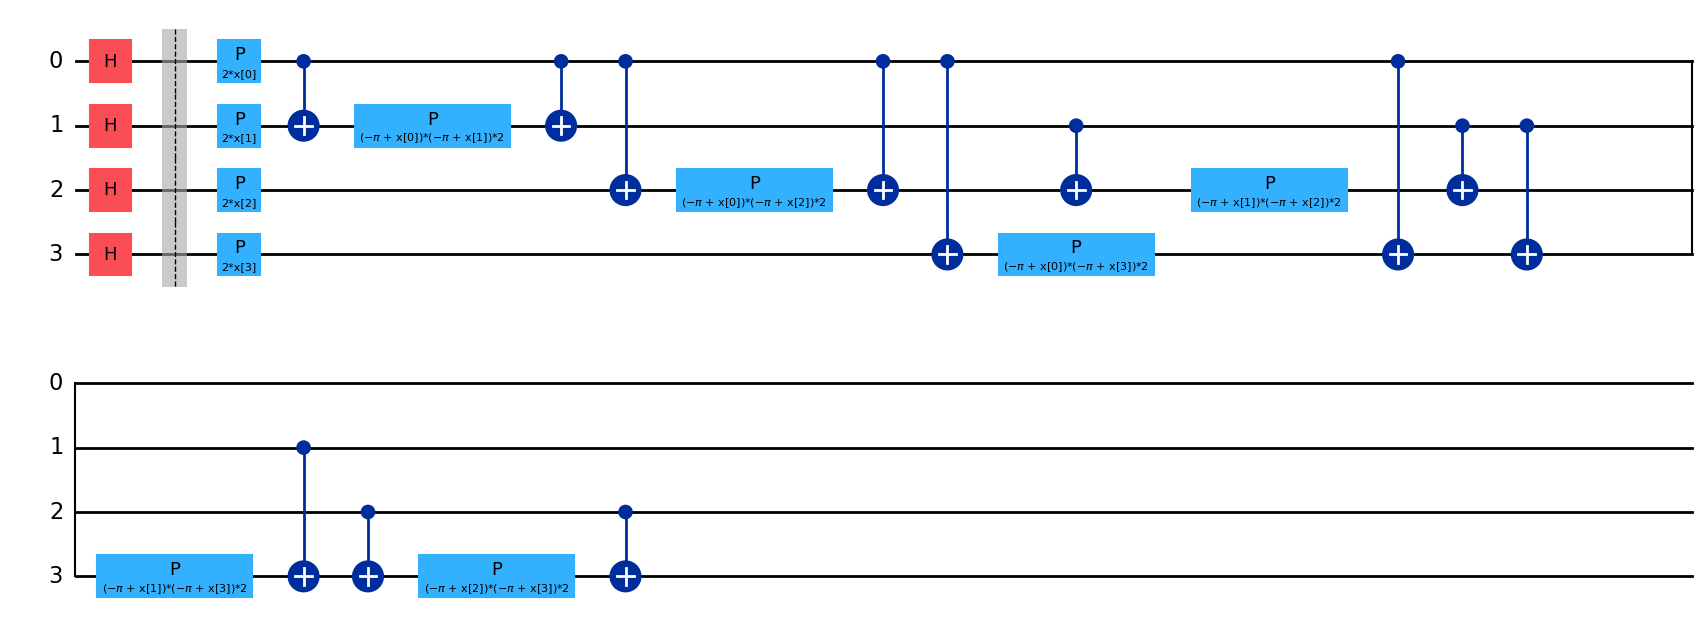

In [13]:
from qiskit.circuit.library import zz_feature_map

map_zz = zz_feature_map(feature_dimension=4, reps=1, entanglement='full', insert_barriers=True)
map_zz.draw('mpl')


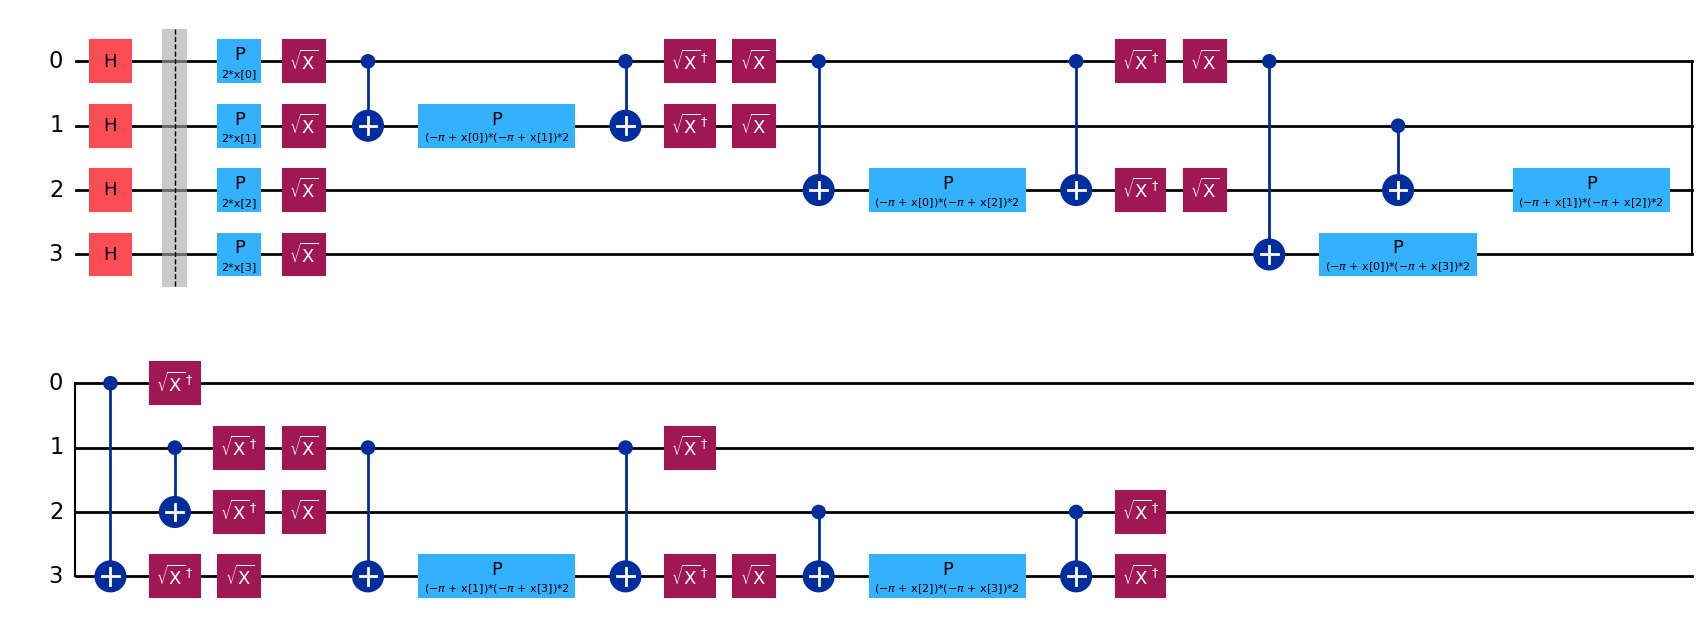

In [14]:
from qiskit.circuit.library import pauli_feature_map

# Ejemplo con rotaciones Z de 1 cúbit y YY de dos cúbits
map_pauli = pauli_feature_map(feature_dimension=4, reps=1, paulis=["Z", "YY"], entanglement='full', insert_barriers=True)
map_pauli.draw('mpl')

#### Problemas con feature maps complejos

Los clasificadores cuánticos solo proporcionan ventaja frente a un los clásicos si el feature map es suficientemente complejo y difícil de simular clásicamente.

Pero si es demasiado complejo (con muchas puertas, alto entrelazamiento o profundidad excesiva)  pueden ocurrir fenómenos indeseables:

  - _Barren plateaus_: El gradiente se desvanece exponencialmente y falla la optimización
  - Overfitting: igual que el caso clásico, un feature map cuántico demasiado complejo puede provocar overfitting, especialmente cuando el conjunto de entrenamiento es pequeño.

## Ejemplo de clasificación binaria con QKE

Ejemplo del [Qiskit Machine Learning Tutorial](https://qiskit.org/documentation/machine-learning/tutorials/03_quantum_kernel.html).

Este ejemplo usa QKE con el usa el dataset descrito en https://arxiv.org/pdf/1804.11326.pdf y obtiene la matriz kernel cuántica. Ver [aquí](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.datasets.ad_hoc_data.html) para detalles sobre los datos.

Para crear la matriz kernel cuántica usa la clase [FidelityQuantumKernel](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.kernels.FidelityQuantumKernel.html).

Como feature_map usa [ZZFeatureMap](https://docs.quantum.ibm.com/api/qiskit/qiskit.circuit.library.ZZFeatureMap).

En la parte clásica, usa el algoritmo [SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC) (_Support Vector Machine Classification_) del módulo de [SVM](https://scikit-learn.org/stable/modules/svm.html) de la librería [scikit-learn](https://scikit-learn.org/stable/).

In [15]:
from qiskit_machine_learning.datasets import ad_hoc_data
from qiskit_machine_learning.utils import algorithm_globals

algorithm_globals.random_seed = 12345

data_dimension = 2
# adhoc_total son todos los puntos en una rejilla uniforme de la que se seleccionan las muestras
train_features, train_labels, test_features, test_labels = ad_hoc_data(
    training_size=20, # 20 datos de cada clase, 40 en total
    test_size=5,      # 5 datos de cada clase, 10 en total
    n=data_dimension,
    gap=0.3,  # Distancia mínima de separación entre las regiones de las dos clases
    plot_data=False,
    one_hot=False,   # Si True, devuelve las etiquetas en formato one-hot.
)


El dataset es bidimensional. Las dos características corresponden a coordenadas $x$ e $y$, y tiene dos clases, con etiquetas A y B. Las siguientes funciones permiten visualizarlo.

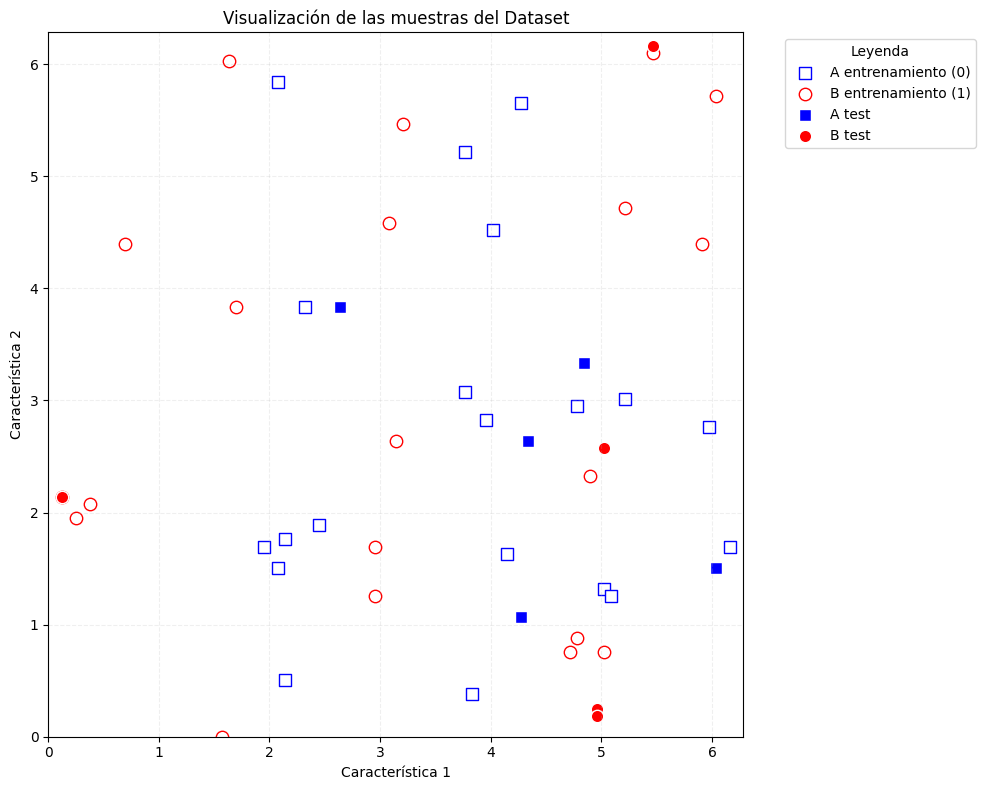

In [16]:
import matplotlib.pyplot as plt
import numpy as np

def plot_features(ax, features, labels, class_label, marker, face, edge, label):
    """Función auxiliar para dibujar puntos con estilo."""
    indices = np.where(labels[:] == class_label)
    ax.scatter(
        features[indices, 0],
        features[indices, 1],
        marker=marker,
        facecolors=face,
        edgecolors=edge,
        label=label,
        s=80, # Tamaño de los puntos aumentado para mejor visibilidad
        linewidths=1 # Borde más grueso
    )

# Definimos parámetros visuales comunes para consistencia
FIG_SIZE = (10, 8)
AXIS_LIMIT = (0, 2 * np.pi)


def visualizar_muestras(train_features, train_labels, test_features, test_labels):
    # Crear figura y configurar ejes para consistencia
    plt.figure(figsize=FIG_SIZE)
    plt.xlim(AXIS_LIMIT)
    plt.ylim(AXIS_LIMIT)

    # 1. Dibujar datos de ENTRENAMIENTO (Borde color, fondo Blanco 'w')
    # Convención: Cuadrado ('s') = Clase A (0), Círculo ('o') = Clase B (1)
    plot_features(plt, train_features, train_labels, 0, "s", "w", "b", "A entrenamiento (0)")
    plot_features(plt, train_features, train_labels, 1, "o", "w", "r", "B entrenamiento (1)")

    # 2. Dibujar datos de TEST (Relleno de color sólido)
    plot_features(plt, test_features, test_labels, 0, "s", "b", "w", "A test")
    plot_features(plt, test_features, test_labels, 1, "o", "r", "w", "B test")

    # Detalles visuales
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Leyenda")
    plt.title("Visualización de las muestras del Dataset")
    plt.xlabel("Característica 1")
    plt.ylabel("Característica 2")
    plt.grid(alpha=0.2, linestyle='--') # Cuadrícula sutil
    plt.tight_layout()
    plt.show()

# Dibuja las muestras
visualizar_muestras(train_features, train_labels, test_features, test_labels)

#### Clasificación clásica






In [17]:
from sklearn.svm import SVC

# Camo feature map usamos Radial Basis Function Kernel
cmodel = SVC(kernel='rbf')

# Entrenamos el modelo
cmodel.fit(train_features, train_labels)

# Obtenemos la score medio de la clasificación de los datos de test
cmodel_score = cmodel.score(test_features, test_labels)

print(f'Score con los datos de test: {cmodel_score}')

Score con los datos de test: 0.7


Calculando 2500 predicciones del modelo... Por favor, espera.


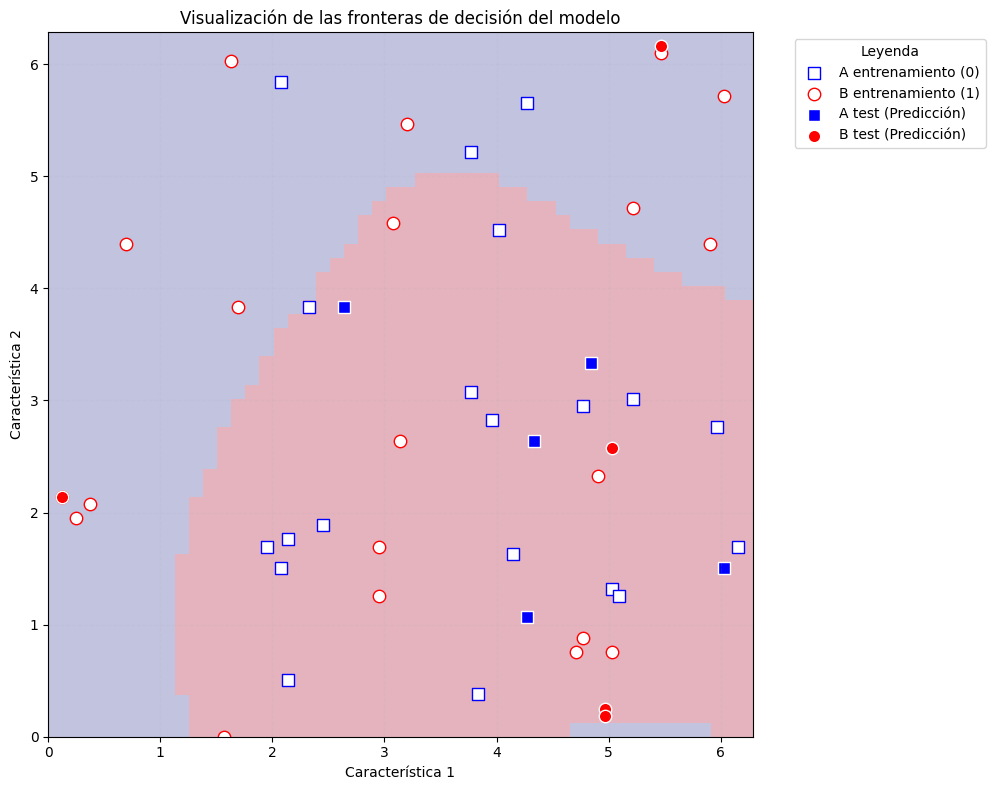

In [18]:
def visualizar_fronteras_y_puntos(model, train_features, train_labels, test_features, test_labels):
    # Crear figura y configurar ejes para consistencia (idéntico al Código 1)
    plt.figure(figsize=FIG_SIZE)
    plt.xlim(AXIS_LIMIT)
    plt.ylim(AXIS_LIMIT)

    # 1. GENERACIÓN DE LA REJILLA DE FRONTERAS (GRID)
    # 50x50 = 2500 predicciones.
    grid_size = 50
    x_range = np.linspace(AXIS_LIMIT[0], AXIS_LIMIT[1], grid_size)
    y_range = np.linspace(AXIS_LIMIT[0], AXIS_LIMIT[1], grid_size)
    xx, yy = np.meshgrid(x_range, y_range)

    # Aplanamos la rejilla para predecir
    grid_samples = np.vstack([xx.ravel(), yy.ravel()]).T

    print(f"Calculando {grid_size**2} predicciones del modelo... Por favor, espera.")
    # El QSVC predice la clase para cada trozo del mapa
    grid_predictions = model.predict(grid_samples)
    grid_predictions = grid_predictions.reshape((grid_size, grid_size))

    # 2. DIBUJAR EL FONDO DE FRONTERAS (El Mosaico)
    # cmap='RdBu' da contraste Azul (Clase A) / Rojo (Clase B)
    # origin='lower' asegura que (0,0) esté abajo a la izquierda
    plt.imshow(
        grid_predictions,
        interpolation="nearest",
        origin="lower",
        cmap="RdYlBu",
        extent=[AXIS_LIMIT[0], AXIS_LIMIT[1], AXIS_LIMIT[0], AXIS_LIMIT[1]],
        alpha=0.3
    )

    # 3. DIBUJAR LOS PUNTOS SOBRE EL FONDO (Mismos parámetros visuales que el Código 1)
    # Entrenamiento
    plot_features(plt, train_features, train_labels, 0, "s", "w", "b", "A entrenamiento (0)")
    plot_features(plt, train_features, train_labels, 1, "o", "w", "r", "B entrenamiento (1)")

    # Test
    plot_features(plt, test_features, test_labels, 0, "s", "b", "w", "A test (Predicción)")
    plot_features(plt, test_features, test_labels, 1, "o", "r", "w", "B test (Predicción)")

    # Detalles visuales comunes
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Leyenda")
    plt.title("Visualización de las fronteras de decisión del modelo")
    plt.xlabel("Característica 1")
    plt.ylabel("Característica 2")
    plt.grid(alpha=0.1, linestyle='--') # Cuadrícula aún más sutil sobre el fondo
    plt.tight_layout()
    plt.show()

# Visualiza la frontera
visualizar_fronteras_y_puntos(cmodel, train_features, train_labels, test_features, test_labels)

#### Clasificación cuántica

Creamos un QuantumKernel para la clasificación. Usaremos un [FidelityQuantumKernel](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.kernels.FidelityQuantumKernel.html) y como feature_map un [ZZFeatureMap](https://quantum.cloud.ibm.com/docs/en/api/qiskit/qiskit.circuit.library.zz_feature_map).

El FidelityQuantumKernel se encarga de automatizar el proceso para calcular la matriz $K$:

 1. Usa el Feature Map que se le pasa como parámetro para codificar los datos clásicos en estados cuánticos.
 2. Usa la clase [ComputeUncompute](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.state_fidelities.ComputeUncompute.html) para obtener las fidelidades entre estados cuánticos.


In [19]:
from qiskit.circuit.library import zz_feature_map
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit.primitives import StatevectorSampler

# Definimos el ZZFeatureMap con 2 repeticiones
feature_map = zz_feature_map(feature_dimension=data_dimension, reps=1, entanglement="linear")

# Definimos el objeto que computa la fidelidad (con el sampler que usa)
fidelidad = ComputeUncompute(sampler=StatevectorSampler())

# Creamos el kernel cuántico
quantum_kernel = FidelityQuantumKernel(feature_map=feature_map, fidelity=fidelidad)

El algoritmo SVC de scikit-learn acepta dos formas de definir un kernel a medida.

La primera es pasándole la función que se encarga de computar la matriz kernel, que es el método evaluate del FidelityQuantumKernel

In [20]:
from sklearn.svm import SVC

# Como feature map usamos el que acabamos de crear
# quantum_kernel.evaluate es la función que calcula la matriz K en el circuito cuántico
qmodel = SVC(kernel=quantum_kernel.evaluate)

# Entrenamos el modelo
qmodel.fit(train_features, train_labels)

# Obtenemos la score medio de la clasificación de los datos de test
qmodel_score = qmodel.score(test_features, test_labels)

print(f'Score con los datos de test: {qmodel_score}')


Score con los datos de test: 1.0


La segunda forma es pasándole la matriz kernel precalculada.

Precalculamos las matrices $K(x_i,x_j)$ y $K(t_i, x_j)$ donde las $x$ son los datos de entrenamiento y las $t$ los de test

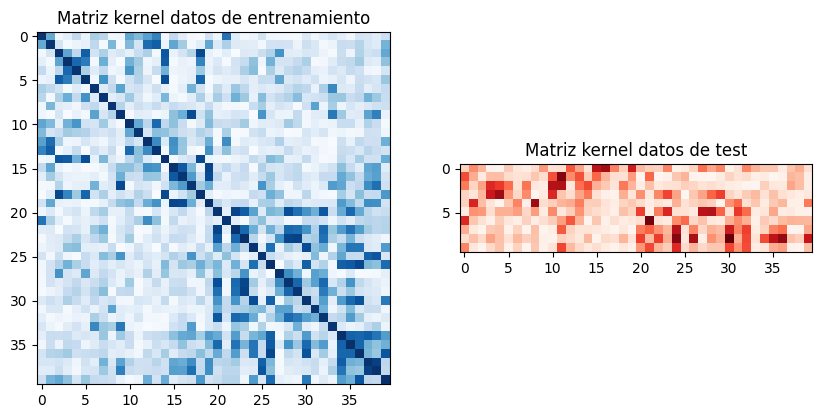

In [21]:
# Obtenemos la matriz kernel para los datos de entrenamiento
k_train = quantum_kernel.evaluate(x_vec=train_features,
                                  y_vec=train_features)

# Obtenemos la matriz kernel para los datos de test
k_test = quantum_kernel.evaluate(x_vec=test_features,
                                 y_vec=train_features)
# Mostramos las matrices
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(np.asmatrix(k_train),
              interpolation='nearest', origin='upper', cmap='Blues')
axs[0].set_title("Matriz kernel datos de entrenamiento")
axs[1].imshow(np.asmatrix(k_test),
              interpolation='nearest', origin='upper', cmap='Reds')
axs[1].set_title("Matriz kernel datos de test")
plt.show()

In [22]:
# Ejecuta el SVC con las matrices precalculadas
qmodel_precomp = SVC(kernel='precomputed')

# Le pasamos la matriz kernel de entrenamiento y las etiquetas
qmodel_precomp.fit(k_train, train_labels)

# Obtenemos la calificación media de la clasificación de los datos de test
qmodel_precomp_score = qmodel_precomp.score(k_test, test_labels)

print(f'Calificación media de los datos de test: {qmodel_precomp_score}')

Calificación media de los datos de test: 1.0


#### Clasificación usando Qiskit Quantum Support Vector Classification (QSVC)

[QSVC](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.algorithms.QSVC.html) es una función de conveniencia proporcionada por Qiskit.


In [23]:
from qiskit_machine_learning.algorithms import QSVC

qsvc = QSVC(quantum_kernel=quantum_kernel)

qsvc.fit(train_features, train_labels)

qsvc_score = qsvc.score(test_features, test_labels)

print(f"QSVC: Calificación media de los datos de test: {qsvc_score}")

QSVC: Calificación media de los datos de test: 1.0


Visualizamos la frontera de decisión (le lleva un rato!)

Calculando 2500 predicciones del modelo... Por favor, espera.


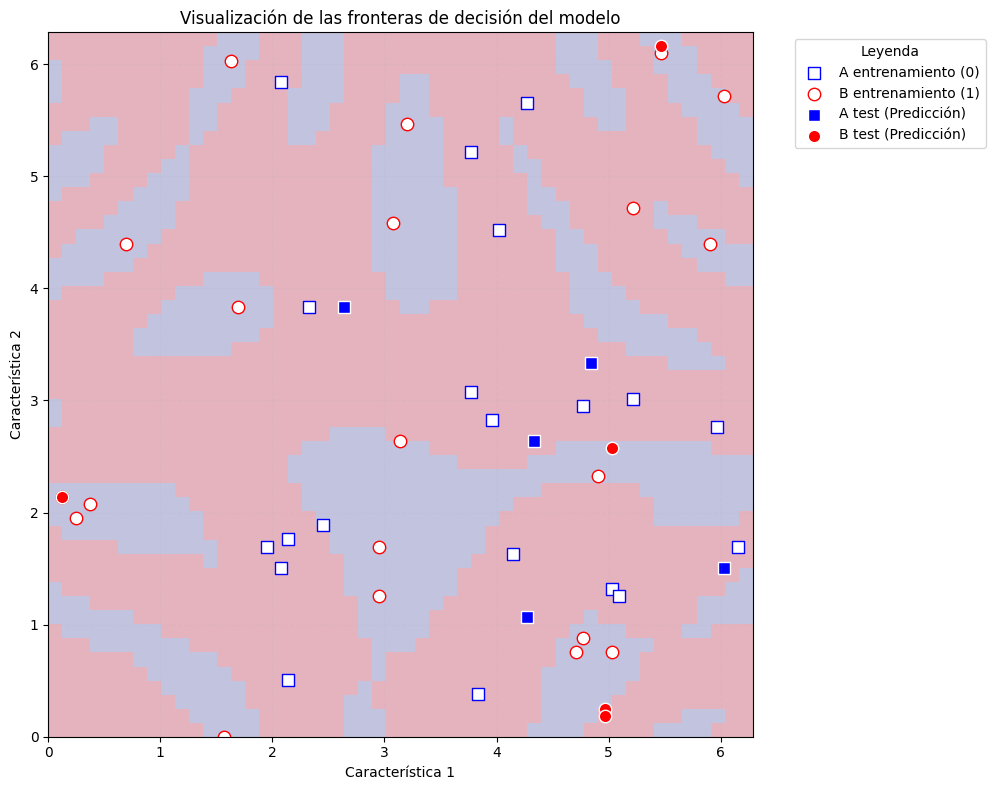

In [24]:
# Visualiza la frontera
visualizar_fronteras_y_puntos(qsvc, train_features, train_labels, test_features, test_labels)

Podemos reconstruir el circuito cuántico que se usa en el proceso de inferencia de la siguiente manera:

El modelo ha seleccionado 26 vectores de soporte de los 40 puntos de entrenamiento.
Índices de los vectores de soporte: [ 0  2  3  4  5  6  7  8  9 12 15 16 17 19 21 23 25 26 27 29 31 33 36 37
 38 39]


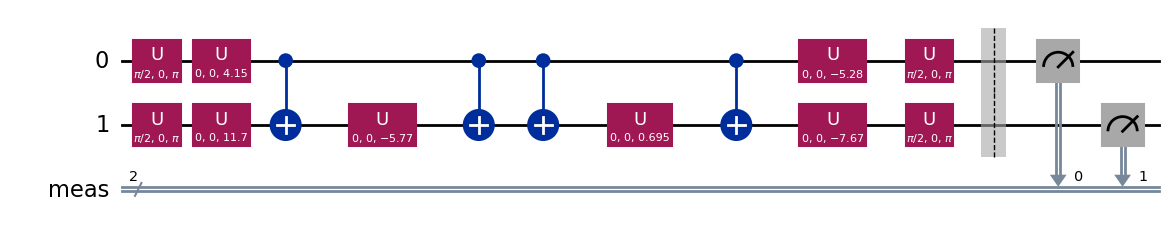

In [25]:
#  Indices de los vectores de soporte
indices_sv = qsvc.support_
print(f"El modelo ha seleccionado {len(indices_sv)} vectores de soporte de los {len(train_features)} puntos de entrenamiento.")
print(f"Índices de los vectores de soporte: {indices_sv}")

# Primer vector de soporte
vector_soporte = train_features[indices_sv[0]]
# Primer punto de test
punto_test = test_features[0]

# Construimos el circuito
feature_map = qsvc.quantum_kernel.feature_map
# ComputeUncompute: Aplicamos el feature map al vector de soporte y después al punto de test (inverso)
circuit_inferencia = feature_map.assign_parameters(vector_soporte).compose(
    feature_map.assign_parameters(punto_test).inverse()
)
# Añadimos las medidas
circuit_inferencia.measure_all()
display(circuit_inferencia.decompose().draw(output='mpl'))




---



---



---



<a name="e9"></a>
# **✍️ Ejercicio entregable 9: dataset de círculos concéntricos**

Usa el dataset `make_circles` de scikit-learn para probar la clasificación binaria con QKE.

*   Usa el algoritmo SVC de scikit-learn pasandole las matrices kernel precalculadas.
*   Prueba con diferentes feature maps (ZZFeatureMap, ZFeatureMap) y diferentes rangos de normalización.



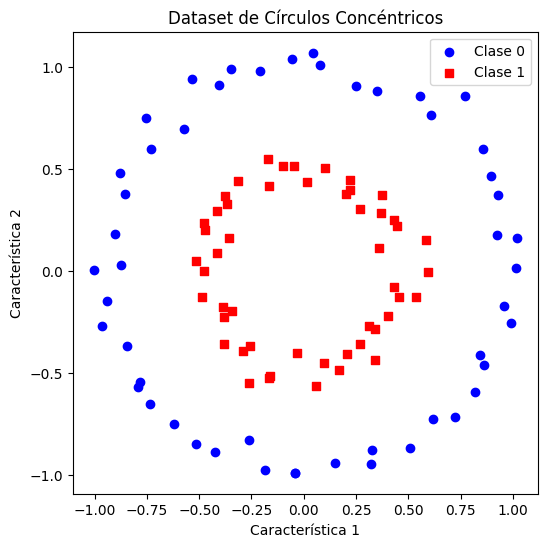

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

seed = 1234
np.random.seed(seed)

# Dataset de círculos
# factor: relación de radio entre el círculo interno y externo (0.5 es buena separación)
# noise: añade dispersión para que no sea un círculo perfecto y sea más realista
features, labels = make_circles(n_samples=100, factor=0.5, noise=0.05, random_state=seed)

# Lo visualización
# Definimos parámetros visuales comunes para consistencia
plt.figure(figsize=(6,6))
for label, color, marker in zip([0, 1], ["blue", "red"], ["o", "s"]):
    mask = labels == label
    plt.scatter(features[mask, 0], features[mask, 1], c=color, label=f"Clase {label}", marker=marker)

plt.title("Dataset de Círculos Concéntricos")
plt.xlabel("Característica 1")
plt.ylabel("Característica 2")
plt.legend()
plt.show()

In [27]:
# División en entrenamiento y test
train_features, test_features, train_labels, test_labels = train_test_split(
    features, labels, train_size=0.8, test_size=0.2, random_state=42
)
# Normalización (Escalado de características)
inf_rango = -np.pi
sup_rango = np.pi
scaler = MinMaxScaler(feature_range=(inf_rango, sup_rango))
train_features = scaler.fit_transform(train_features)
test_features = scaler.transform(test_features)

#### Clasificación clásica

In [28]:
from sklearn.svm import SVC

# Camo feature map usamos Radial Basis Function Kernel
cmodel = SVC(kernel='rbf')

# Entrenamos el modelo
cmodel.fit(train_features, train_labels)

# Obtenemos la score medio de la clasificación de los datos de test
cmodel_score = cmodel.score(test_features, test_labels)

print(f'Score con los datos de test: {cmodel_score}')

Score con los datos de test: 1.0


Visualizamos datos y frontera de separación

Calculando 2500 predicciones del modelo... Por favor, espera.


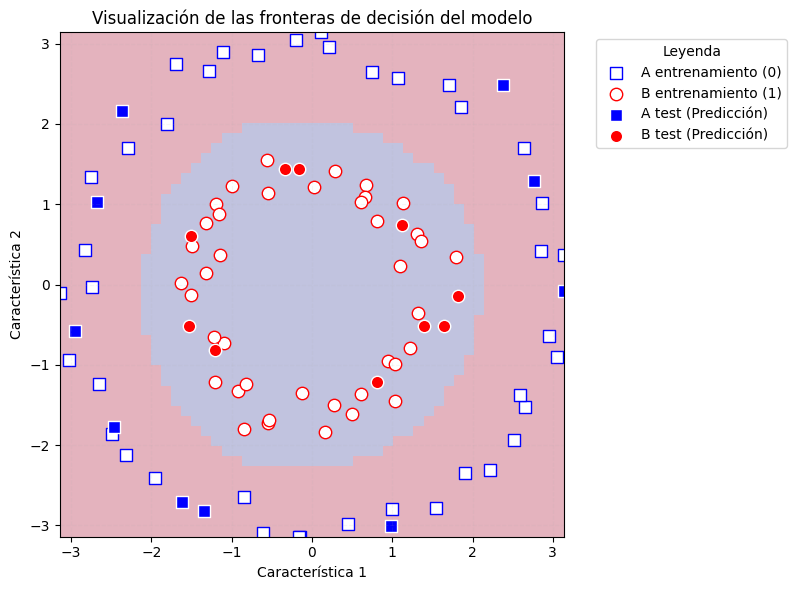

In [29]:
FIG_SIZE = (8, 6)
AXIS_LIMIT = (inf_rango, sup_rango)

def plot_features(ax, features, labels, class_label, marker, face, edge, label):
    """Función auxiliar para dibujar puntos con estilo."""
    indices = np.where(labels[:] == class_label)
    ax.scatter(
        features[indices, 0],
        features[indices, 1],
        marker=marker,
        facecolors=face,
        edgecolors=edge,
        label=label,
        s=80, # Tamaño de los puntos aumentado para mejor visibilidad
        linewidths=1 # Borde más grueso
    )

def visualizar_fronteras_y_puntos(model, train_features, train_labels, test_features, test_labels):
    # Crear figura y configurar ejes para consistencia (idéntico al Código 1)
    plt.figure(figsize=FIG_SIZE)
    plt.xlim(AXIS_LIMIT)
    plt.ylim(AXIS_LIMIT)

    # 1. GENERACIÓN DE LA REJILLA DE FRONTERAS (GRID)
    # 50x50 = 2500 predicciones.
    grid_size = 50
    x_range = np.linspace(AXIS_LIMIT[0], AXIS_LIMIT[1], grid_size)
    y_range = np.linspace(AXIS_LIMIT[0], AXIS_LIMIT[1], grid_size)
    xx, yy = np.meshgrid(x_range, y_range)

    # Aplanamos la rejilla para predecir
    grid_samples = np.vstack([xx.ravel(), yy.ravel()]).T

    print(f"Calculando {grid_size**2} predicciones del modelo... Por favor, espera.")
    # El QSVC predice la clase para cada trozo del mapa
    grid_predictions = model.predict(grid_samples)
    grid_predictions = grid_predictions.reshape((grid_size, grid_size))

    # 2. DIBUJAR EL FONDO DE FRONTERAS (El Mosaico)
    # cmap='RdBu' da contraste Azul (Clase A) / Rojo (Clase B)
    # origin='lower' asegura que (0,0) esté abajo a la izquierda
    plt.imshow(
        grid_predictions,
        interpolation="nearest",
        origin="lower",
        cmap="RdYlBu",
        extent=[AXIS_LIMIT[0], AXIS_LIMIT[1], AXIS_LIMIT[0], AXIS_LIMIT[1]],
        alpha=0.3
    )

    # 3. DIBUJAR LOS PUNTOS SOBRE EL FONDO (Mismos parámetros visuales que el Código 1)
    # Entrenamiento
    plot_features(plt, train_features, train_labels, 0, "s", "w", "b", "A entrenamiento (0)")
    plot_features(plt, train_features, train_labels, 1, "o", "w", "r", "B entrenamiento (1)")

    # Test
    plot_features(plt, test_features, test_labels, 0, "s", "b", "w", "A test (Predicción)")
    plot_features(plt, test_features, test_labels, 1, "o", "r", "w", "B test (Predicción)")

    # Detalles visuales comunes
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", title="Leyenda")
    plt.title("Visualización de las fronteras de decisión del modelo")
    plt.xlabel("Característica 1")
    plt.ylabel("Característica 2")
    plt.grid(alpha=0.1, linestyle='--') # Cuadrícula aún más sutil sobre el fondo
    plt.tight_layout()
    plt.show()

# Visualiza la frontera
visualizar_fronteras_y_puntos(cmodel, train_features, train_labels, test_features, test_labels)

#### Clasificación cuántica

Haz la clasificación usando QKE

*   Recuerda probar con diferentes feature maps y diferentes rangos de normalización



In [30]:
# División en entrenamiento y test
train_features, test_features, train_labels, test_labels = train_test_split(
    features, labels, train_size=0.8, test_size=0.2, random_state=42
)
# Normalización (Escalado de características)
inf_rango = -np.pi
sup_rango = np.pi
scaler = MinMaxScaler(feature_range=(inf_rango, sup_rango))
train_features = scaler.fit_transform(train_features)
test_features = scaler.transform(test_features)

In [32]:
# Kernel cuántico con el mismo feature map definido anteriormente
qsvc = QSVC(quantum_kernel=quantum_kernel)

qsvc.fit(train_features, train_labels)

qsvc_score = qsvc.score(test_features, test_labels)

print(f"QSVC: Calificación media de los datos de test: {qsvc_score}")

QSVC: Calificación media de los datos de test: 0.4


Calculando 2500 predicciones del modelo... Por favor, espera.


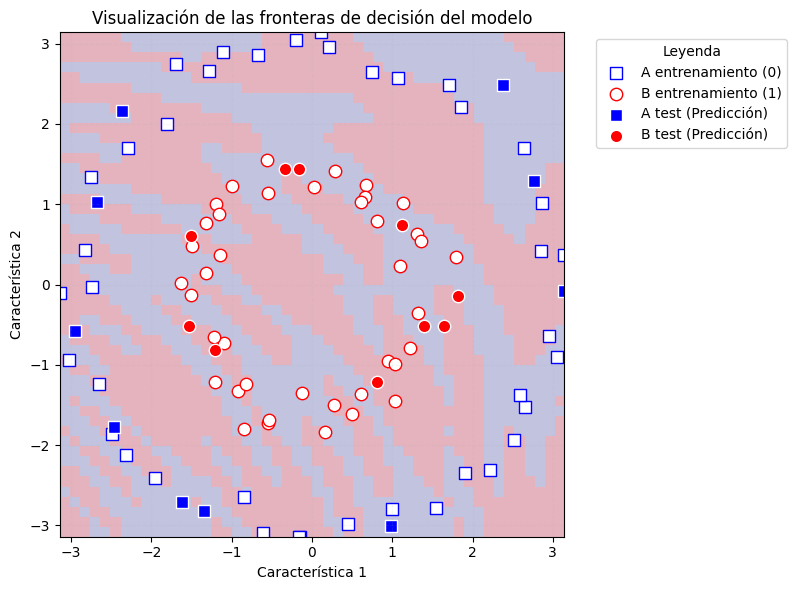

In [33]:
visualizar_fronteras_y_puntos(qsvc, train_features, train_labels, test_features, test_labels)

In [34]:
# Diferente normalización (entre 0 y 1)

train_features, test_features, train_labels, test_labels = train_test_split(
    features, labels, train_size=0.8, test_size=0.2, random_state=42
)
inf_rango = 0
sup_rango = 1


scaler = MinMaxScaler(feature_range=(inf_rango, sup_rango))
train_features = scaler.fit_transform(train_features)
test_features = scaler.transform(test_features)

In [35]:
qsvc = QSVC(quantum_kernel=quantum_kernel)

qsvc.fit(train_features, train_labels)

qsvc_score = qsvc.score(test_features, test_labels)

print(f"QSVC: Calificación media de los datos de test: {qsvc_score}")

QSVC: Calificación media de los datos de test: 0.9


Calculando 2500 predicciones del modelo... Por favor, espera.


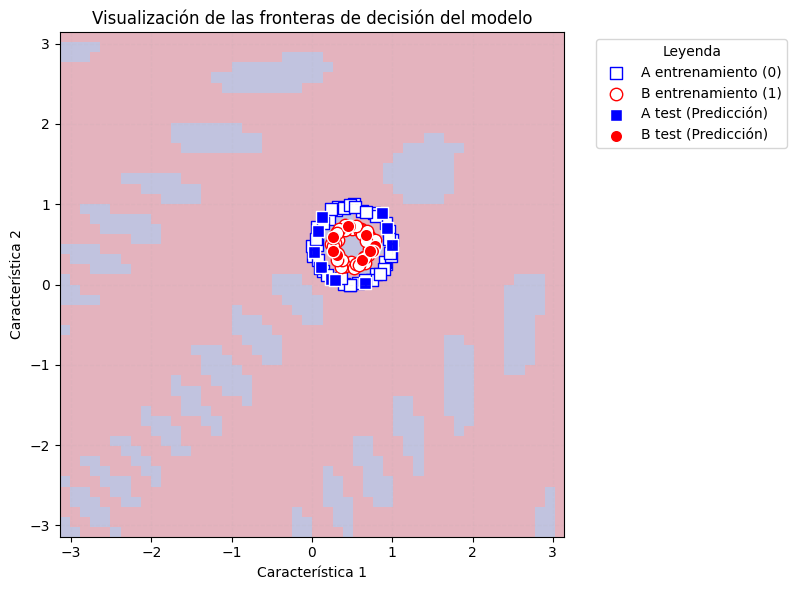

In [36]:
visualizar_fronteras_y_puntos(qsvc, train_features, train_labels, test_features, test_labels)

In [47]:
# Diferente normalización (entre -1 y 1)
features, labels = make_circles(n_samples=100, factor=0.7, noise=0.15, random_state=seed)

train_features, test_features, train_labels, test_labels = train_test_split(
    features, labels, train_size=0.8, test_size=0.2, random_state=42
)
inf_rango = -1
sup_rango = 1


scaler = MinMaxScaler(feature_range=(inf_rango, sup_rango))
train_features = scaler.fit_transform(train_features)
test_features = scaler.transform(test_features)

In [48]:
# diferente feature map cuantico
feature_map = z_feature_map(feature_dimension=data_dimension, reps=2, entanglement="full")
fidelidad = ComputeUncompute(sampler=StatevectorSampler())
quantum_kernel_2 = FidelityQuantumKernel(feature_map=feature_map, fidelity=fidelidad)

qsvc = QSVC(quantum_kernel=quantum_kernel_2)

qsvc.fit(train_features, train_labels)

qsvc_score = qsvc.score(test_features, test_labels)

print(f"QSVC: Calificación media de los datos de test: {qsvc_score}")

QSVC: Calificación media de los datos de test: 0.85


Calculando 2500 predicciones del modelo... Por favor, espera.


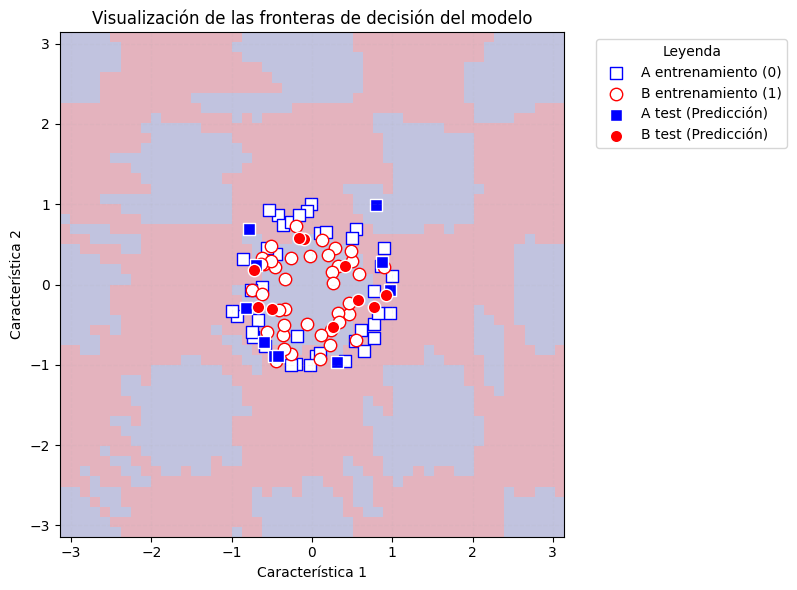

In [39]:
visualizar_fronteras_y_puntos(qsvc, train_features, train_labels, test_features, test_labels)

In [ ]:
# División en entrenamiento y test
features, labels = make_circles(n_samples=100, factor=0.7, noise=0.15, random_state=seed)

train_features, test_features, train_labels, test_labels = train_test_split(
    features, labels, train_size=0.8, test_size=0.2, random_state=42
)
inf_rango = -1
sup_rango = 1

# inf_rango = 0
# sup_rango = np.pi

# inf_rango = 0
# sup_rango = 2 * np.pi

# inf_rango = -np.pi / 2
# sup_rango = np.pi / 2

scaler = MinMaxScaler(feature_range=(inf_rango, sup_rango))
train_features = scaler.fit_transform(train_features)
test_features = scaler.transform(test_features)

In [ ]:
# diferente feature map cuantico

feature_map = z_feature_map(feature_dimension=data_dimension, reps=2, entanglement="full")
fidelidad = ComputeUncompute(sampler=StatevectorSampler())
quantum_kernel = FidelityQuantumKernel(feature_map=feature_map, fidelity=fidelidad)
qsvc = QSVC(quantum_kernel=quantum_kernel)
qsvc.fit(train_features, train_labels)
qsvc_score = qsvc.score(test_features, test_labels)




---



---



---



<a name="qnn"></a>
# **Redes neuronales cuánticas (QNNs)**

<center><img src="https://drive.google.com/uc?export=view&id=1nk0FNNO_T7JiByRYDfabypqXU7Vj1m9P" alt="QNN" width="900"  /></center>
Fuente: <a href=https://qiskit-community.github.io/qiskit-machine-learning/tutorials/01_neural_networks.html target=_blank>href=https://qiskit-community.github.io/qiskit-machine-learning/tutorials/01_neural_networks.html</a>

Extensión del Variational Quantum Classifier con una estructura similar a una red neuronal:

1. Capa de entrada: un feature map para codificar las entradas como estados cuánticos
2. Capas intermedias: circuitos parametrizados (denominados *forma variacional* o *ansatz*) con rotaciones parametrizadas y puertas de entrelazamiento (CNOTs u otras)
3. Capa de salida: medida del circuito. Puede ser las probabilidades de cada estado o el valor esperado de un observable.
4. Un optimizador clásico que optimiza los parámetros de las rotaciones.

Más información: <a href=https://qiskit-community.github.io/qiskit-machine-learning/tutorials/ target=_blank>Qiskit Machine Learning Tutorials</a>

#### Capa de salida

La medida del estado cuántico introduce no-linealidad en la QNN.

- Pueden tomarse diferentes medidas: probabilidades de los estados, valores de un observable, etc.

Una elección de medida es obtener el valor esperado del observable $Z\otimes Z\otimes\ldots\otimes Z$

El valor de ese observable para un estado genérico $|\psi\rangle = \sum_{x\in \{0,1\}^n} \alpha_i|x_i\rangle$ es:

$$
\langle\psi|ZZ\ldots Z|\psi\rangle = \sum_{x\in \{0,1\}^n} |\alpha_i|^2 (-1)^{\text{paridad}(x)}
$$

siendo $\text{paridad}(x) = 0$ si el número de 1s en la representación binaria de $x$ es par y $\text{paridad}(x) = 1$ si es impar.

## **Ejemplos de formas variacionales**

Existen muchos ejemplos de formas variacionales o ansätze en la literatura.

Un ansatz eficiente debería:

- Minimizar el número de puertas y la profundidad del circuito.
- Usar preferiblemente las puertas nativas del hardware
- Ser robusto frente al fenómeno de los *barren plateaus*.

Los ansätze mas usados se pueden clasificar, grosso modo, en:

- Hardware-efficient ansätze: pensados para adaptarse al hardware disponible.
- Problem-inspired ansätze:  especialmente adaptados al problema a resolver


### Ejemplos de ansätze implementados en Qiskit

- **RealAmplitudes**: Ejemplo de Hardware-efficient
  - Utiliza puertas de rotación $R_y$ y entrelazamiento mediante puertas CNOT.
  - Solo genera amplitudes reales, (eficiente en tareas de clasificación)

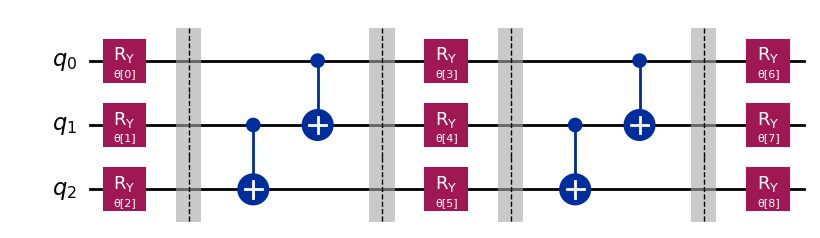

In [40]:
from qiskit.circuit.library import real_amplitudes

ansatz = real_amplitudes(3, reps=2, insert_barriers=True)
ansatz.draw("mpl")

- **EfficientSU2**: Capas de puertas de rotación (puertas de Pauli, $R_x$, $R_y$, $R_z$) seguidas de entrelazamiento con CNOT.
  - Diferentes estrategias de conectividad (lineal, circular, todos-con-todos).

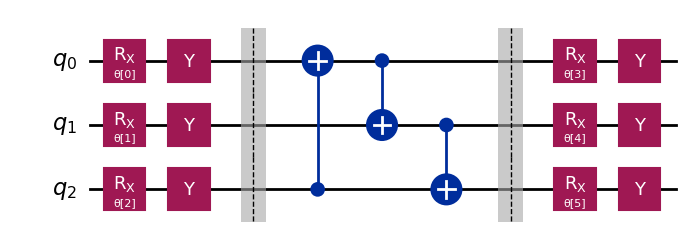

In [41]:
from qiskit.circuit.library import efficient_su2

ansatz = efficient_su2(3, su2_gates=["rx", "y"], entanglement="circular", reps=1, insert_barriers=True)
ansatz.draw("mpl")

- **NLocal**: Forma más genérica.
  - Permite elegir cualquier puerta de rotación y cualquier tipo de entrelazamiento (CNOT, CZ, etc.)
  - Diferentes estrategias de conectividad (lineal, circular, todos-con-todos).

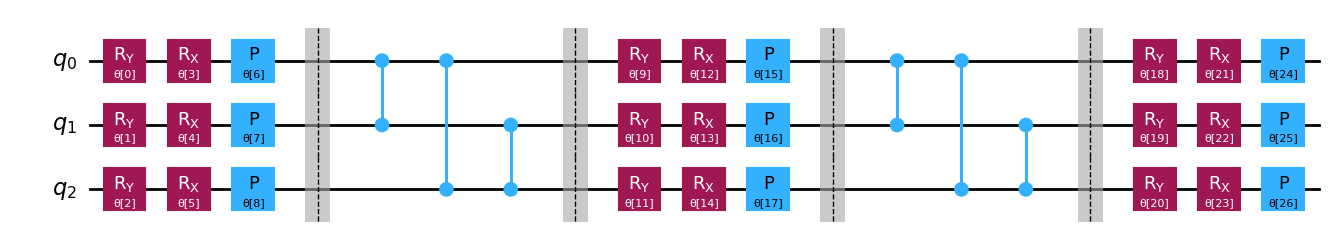

In [42]:
from qiskit.circuit.library import n_local

ansatz = n_local(3, ["ry", "rx", "p"], "cz", "full", reps=2, insert_barriers=True)
ansatz.draw("mpl")



---



---



---



<a name="e10"></a>
# **✍️ Ejercicio entregable 10: Quantum Feedforward Neural Network simple**

Haz un circuito cuántico que implemente una red neuronal feedforward simple de 2 cúbits, con las siguientes características:
1. Como feature map usa ZZFeatureMap
2. Como ansatz usa RealAmplitudes
3. Selecciona pesos aleatorios (mantén los mismos pesos en todas las ejecuciones)
3. Como medida, toma el valor esperado del observable $Z\otimes Z$ (usa un StatevectorEstimator). Esta medida devolverá un valor en el intervalo $[-1, 1]$.
4. Asigna las etiquetas predichas a $0$ o $1$ según el signo

Usa como parámetros de entrada los datos del ejercicio 9 y comprueba si es capaz de clasificar algo.

Prueba otras combinaciones de feature maps (p.e. ZFeatureMap) y ansätze (p.e. EfficientSU2) y con varias capas y rangos de normalización.

In [50]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_circles
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

seed = 1234
np.random.seed(seed)

# Dataset de círculos
# factor: relación de radio entre el círculo interno y externo (0.5 es buena separación)
# noise: añade dispersión para que no sea un círculo perfecto y sea más realista
features, labels = make_circles(n_samples=100, factor=0.5, noise=0.05, random_state=seed)

# Normalización (Escalado de características)
inf_rango = -np.pi
sup_rango = np.pi

scaler = MinMaxScaler(feature_range=(inf_rango, sup_rango))
features = scaler.fit_transform(features)

Accuracy del modelo: 0.37


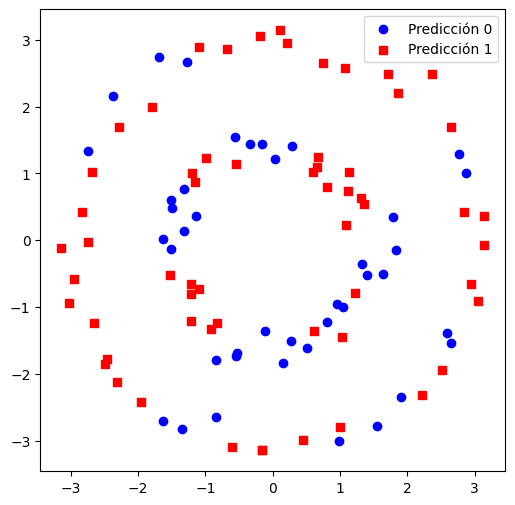

In [106]:
from qiskit.quantum_info import Statevector, SparsePauliOp

# 2 qubits para codificar las 2 características
qubits = 2

# zz feature map
feature_map = zz_feature_map(
    feature_dimension=qubits, reps=2, entanglement="full", insert_barriers=True
)
# ansatz con real amplitudes
ansatz = real_amplitudes(
    num_qubits=qubits, reps=2, entanglement="full", insert_barriers=True
)
# pesos aleatorios para el ansatz
np.random.seed(seed)
weights = np.random.uniform(inf_rango, sup_rango, size=ansatz.num_parameters)

# valor esperado observable Z x Z 
observable = SparsePauliOp.from_list([("ZZ", 1)])

# prediccion 0 o 1 dependiendo del valor esperado
predicciones = []
for x in features:
    # Circuito con el feature map y el ansatz
    circuito = feature_map.assign_parameters(x).\
        compose(ansatz.assign_parameters(weights))
        
    # Estado final y estado esperado entre [-1, 1]
    estado_final = Statevector.from_instruction(circuito)
    valor_esperado = np.real(estado_final.expectation_value(observable))
    # guardamos la prediccion
    prediccion = 0 if valor_esperado < 0 else 1
    predicciones.append(prediccion) 
    
# calculo accuracy
accuracy = np.mean(predicciones == labels)
print(f"Accuracy del modelo: {accuracy:.2f}")
    
# Visualizamos las predicciones
plt.figure(figsize=(6,6))
for label, color, marker in zip([0, 1], ["blue", "red"], ["o", "s"]):
    mask = np.array(predicciones) == label
    plt.scatter(features[mask, 0], features[mask, 1], c=color, label=f"Predicción {label}", marker=marker)
    
plt.legend()
plt.show()




### Prueba otras combinaciones de feature maps (p.e. ZFeatureMap) y ansätze (p.e. EfficientSU2) y con varias capas y rangos de normalización.

Rango [-3.142, 3.142] | capas=1 | accuracy=0.40
Rango [-3.142, 3.142] | capas=2 | accuracy=0.47
Rango [-3.142, 3.142] | capas=3 | accuracy=0.54
Rango [-3.142, 3.142] | capas=4 | accuracy=0.49
Rango [-3.142, 3.142] | capas=5 | accuracy=0.44
Rango [-3.142, 3.142] | capas=6 | accuracy=0.51
Rango [-3.142, 3.142] | capas=7 | accuracy=0.52
Rango [-3.142, 3.142] | capas=8 | accuracy=0.55
Rango [0.000, 3.142] | capas=1 | accuracy=0.56
Rango [0.000, 3.142] | capas=2 | accuracy=0.30
Rango [0.000, 3.142] | capas=3 | accuracy=0.61
Rango [0.000, 3.142] | capas=4 | accuracy=0.63
Rango [0.000, 3.142] | capas=5 | accuracy=0.63
Rango [0.000, 3.142] | capas=6 | accuracy=0.56
Rango [0.000, 3.142] | capas=7 | accuracy=0.50
Rango [0.000, 3.142] | capas=8 | accuracy=0.42
Rango [0.000, 6.283] | capas=1 | accuracy=0.40
Rango [0.000, 6.283] | capas=2 | accuracy=0.56
Rango [0.000, 6.283] | capas=3 | accuracy=0.48
Rango [0.000, 6.283] | capas=4 | accuracy=0.53
Rango [0.000, 6.283] | capas=5 | accuracy=0.60
Rango

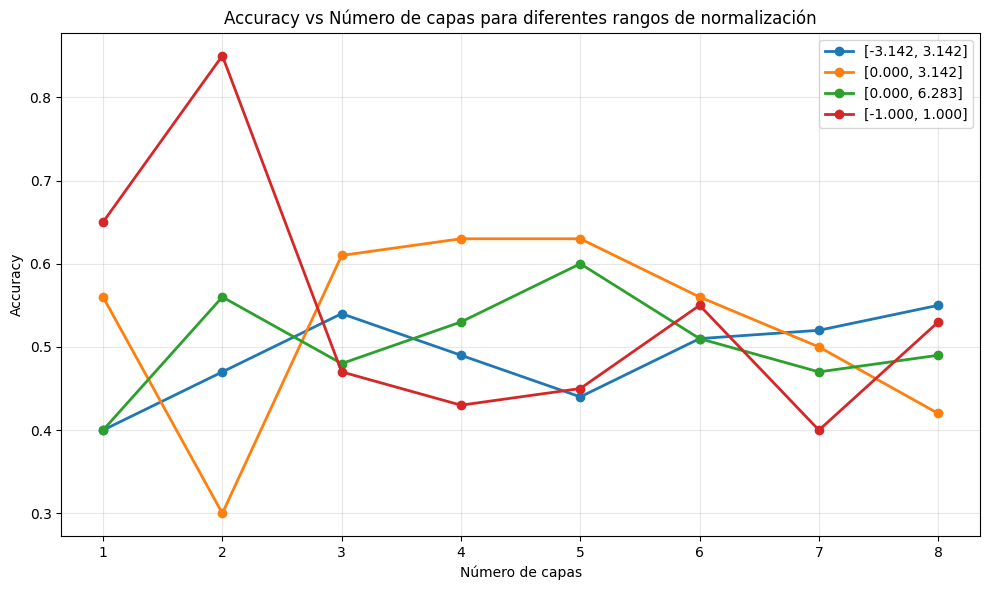

In [111]:
# Base de datos (sin sobrescribir labels)
features_base = features.copy()
labels_base = labels.copy()

# Configuraciones a probar
rangos = [
    (-np.pi, np.pi),
    (0, np.pi),
    (0, 2 * np.pi),
    (-1, 1),
]
capas = range(1, 9)  # De 1 a 8 capas

observable = SparsePauliOp.from_list([("ZZ", 1)])
resultados = []

for inf_rango, sup_rango in rangos:
    # Escalado para este rango
    scaler = MinMaxScaler(feature_range=(inf_rango, sup_rango))
    features_scaled = scaler.fit_transform(features_base)

    for reps in capas:
        # Feature map y ansatz con varias capas
        feature_map = z_feature_map(
            feature_dimension=qubits,reps=reps,insert_barriers=True
        )
        ansatz = efficient_su2(
            num_qubits=qubits,reps=reps,entanglement="full",insert_barriers=True
        )

        rng = np.random.default_rng(seed + reps)
        weights = rng.uniform(inf_rango, sup_rango, size=ansatz.num_parameters)

        predicciones = []
        for x in features_scaled:
            circuito = feature_map.assign_parameters(x).compose(
                ansatz.assign_parameters(weights)
            )
            estado_final = Statevector.from_instruction(circuito)
            valor_esperado = np.real(estado_final.expectation_value(observable))
            predicciones.append(0 if valor_esperado < 0 else 1)

        acc = np.mean(np.array(predicciones) == labels_base)
        resultados.append((inf_rango, sup_rango, reps, acc))
        print(f"Rango [{inf_rango:.3f}, {sup_rango:.3f}] | capas={reps} | accuracy={acc:.2f}")

# Mejor configuración
mejor = max(resultados, key=lambda t: t[3])
print("\nMejor configuración:")
print(f"Rango [{mejor[0]:.3f}, {mejor[1]:.3f}] | capas={mejor[2]} | accuracy={mejor[3]:.2f}")

# Visualizar resultados
plt.figure(figsize=(10, 6))

for inf_rango, sup_rango in rangos:
    capas_list = []
    accuracy_list = []
    for inf, sup, capa, acc in resultados:
        if inf == inf_rango and sup == sup_rango:
            capas_list.append(capa)
            accuracy_list.append(acc)
    
    label_rango = f"[{inf_rango:.3f}, {sup_rango:.3f}]"
    plt.plot(capas_list, accuracy_list, marker='o', label=label_rango, linewidth=2)

plt.xlabel("Número de capas")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Número de capas para diferentes rangos de normalización")
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(capas)
plt.tight_layout()
plt.show()


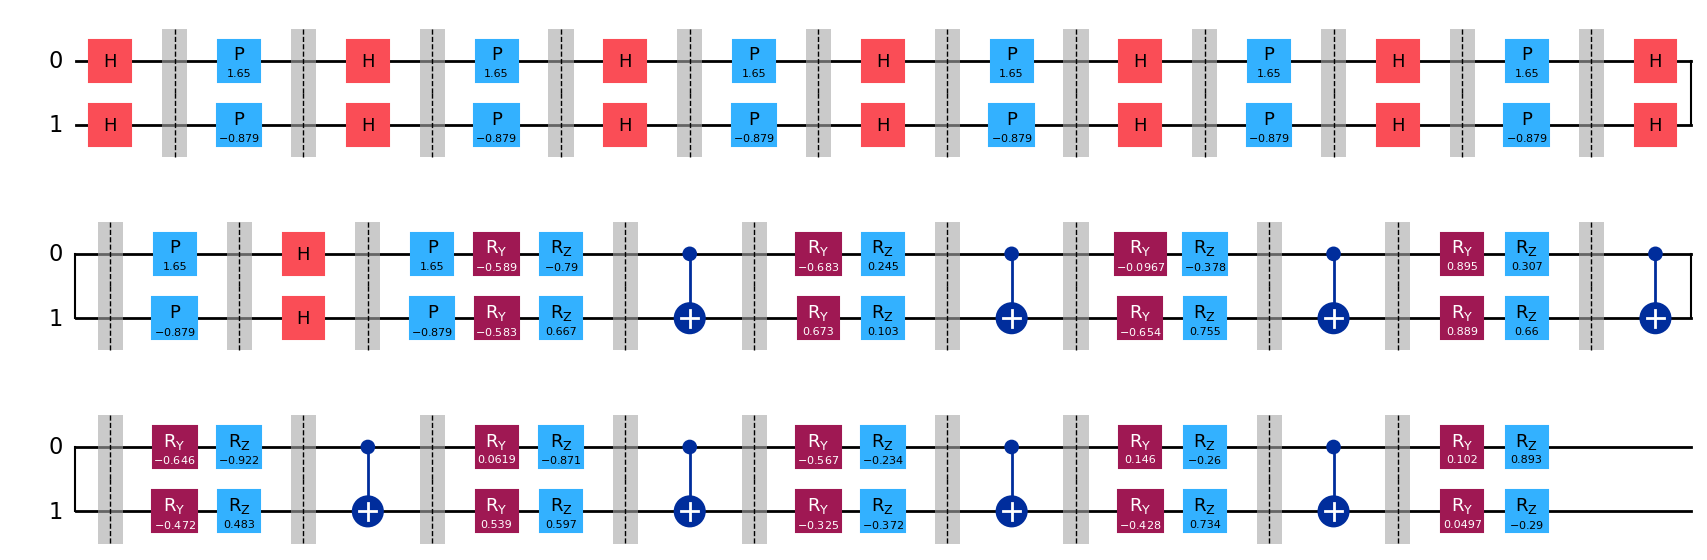

In [115]:
display(circuito.draw("mpl"))
# circuito de 8 capas




---



---



---



<a name="e11"></a>
# **✍️ Ejercicio entregable 11: red con data reuploading**

Repite el ejercicio 10 introduciendo una capa de data reuploading entre dos ansätze. Prueba a usar un feature map diferente en cada capa de data reuploading.

Accuracy: 0.69


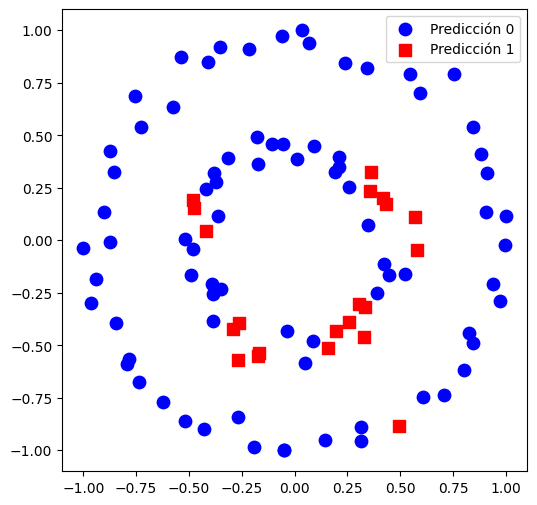

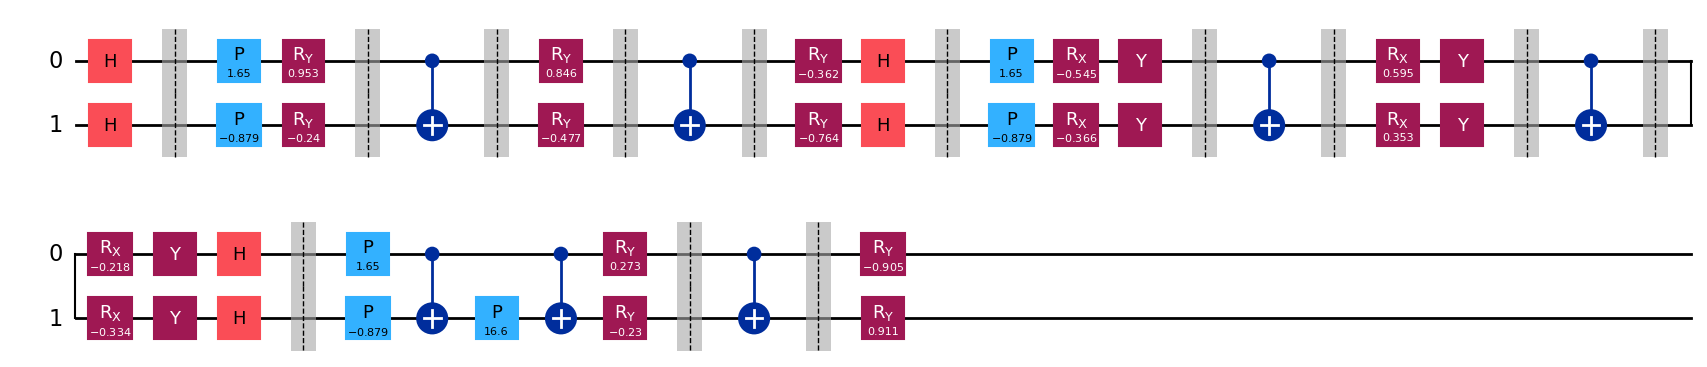

In [125]:
# Configuración inicial
features = features_base.copy()
labels = labels_base.copy()

scaler = MinMaxScaler(feature_range=(inf_rango, sup_rango))
features_scaled = scaler.fit_transform(features)

# Primera capa: ansatz inicial
ansatz1 = real_amplitudes(num_qubits=qubits, reps=2, entanglement="full", insert_barriers=True)
rng1 = np.random.default_rng(1234)
weights_ansatz1 = rng1.uniform(inf_rango, sup_rango, size=ansatz1.num_parameters)

# Segunda capa: reuploading con Z feature map
feature_map_reupl1 = z_feature_map(feature_dimension=qubits, reps=1, entanglement="linear", insert_barriers=True)

# Tercera capa: otro ansatz
ansatz2 = efficient_su2(num_qubits=qubits, su2_gates=["rx", "y"], entanglement="linear", reps=2, insert_barriers=True)
rng2 = np.random.default_rng(12345)
weights_ansatz2 = rng2.uniform(inf_rango, sup_rango, size=ansatz2.num_parameters)

# Cuarta capa: reuploading con ZZ feature map (diferente al anterior)
feature_map_reupl2 = zz_feature_map(feature_dimension=qubits, reps=1, entanglement="linear", insert_barriers=True)

# Quinta capa: tercer ansatz
ansatz3 = real_amplitudes(num_qubits=qubits, reps=1, entanglement="linear", insert_barriers=True)
rng3 = np.random.default_rng(123456)
weights_ansatz3 = rng3.uniform(inf_rango, sup_rango, size=ansatz3.num_parameters)

# Observable 
observable = SparsePauliOp.from_list([("ZZ", 1)])

# Feature map base
feature_map_base = z_feature_map(feature_dimension=qubits, reps=1, insert_barriers=True)

# Predicciones con data reuploading múltiple
predicciones_reupl = []

for x in features_scaled:
    circuito = feature_map_base.assign_parameters(x)
    
    # Primer ansatz
    circuito = circuito.compose(ansatz1.assign_parameters(weights_ansatz1))
    
    # Primer reuploading con Z feature map
    circuito = circuito.compose(feature_map_reupl1.assign_parameters(x))
    
    # Segundo ansatz
    circuito = circuito.compose(ansatz2.assign_parameters(weights_ansatz2))
    
    # Segundo reuploading con ZZ feature map (diferente)
    circuito = circuito.compose(feature_map_reupl2.assign_parameters(x))
    
    # Tercer ansatz
    circuito = circuito.compose(ansatz3.assign_parameters(weights_ansatz3))
    
    # Medir estado
    estado_final = Statevector.from_instruction(circuito)
    valor_esperado = np.real(estado_final.expectation_value(observable))
    prediccion = 0 if valor_esperado < 0 else 1
    predicciones_reupl.append(prediccion)

# Accuracy
accuracy_reupl = np.mean(np.array(predicciones_reupl) == labels)
print(f"Accuracy: {accuracy_reupl:.2f}")


plt.figure(figsize=(6, 6))
for label, color, marker in zip([0, 1], ["blue", "red"], ["o", "s"]):
    mask = np.array(predicciones_reupl) == label
    plt.scatter(features_scaled[mask, 0], features_scaled[mask, 1], 
                c=color, label=f"Predicción {label}", marker=marker, s=80)

plt.legend()
plt.show()

display(circuito.draw("mpl"))



---



---



---



<a name="qnnqiskit"></a>
# **QNNs en Qiskit**

Qiskis tiene funciones de alto nivel para crear diferentes tipos redes neuronales cuánticas simples e híbridas.

  - Nos centraremos en el caso de clasificadores binarios



## **EstimadorQNN y SamplerQNN**

En una QNN en Qiskit tenemos que elegir entre dos formas de realizar la medida:

  - [EstimatorQNN](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.neural_networks.EstimatorQNN.html): mide el valor esperado de un observable (por defecto, $Z\otimes Z\otimes\ldots\otimes Z$)
    - Normalmente un valor real en $[-1,1]$
    - Problemas de regresión o clasificación
  - [SamplerQNN](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.neural_networks.SamplerQNN.html): mide las probabilidades de los diferentes estados
    - Permite definir una función *interpret* para procesar los datos
    - Problemas de clasificación

In [ ]:
# Usamos los siguientes datos para clasificación binaria
import matplotlib.pyplot as plt
from qiskit_machine_learning.utils import algorithm_globals

num_features = 2
num_clases = 2
num_samples = 20
X = 2 * algorithm_globals.random.random([num_samples, num_features]) - 1
y01 = 1 * (np.sum(X, axis=1) >= 0)  # etiquetas { 0,  1}
y = 2 * y01 - 1  # etiquetas {-1, +1}

for x, y_target in zip(X, y):
    if y_target == 1:
        plt.plot(x[0], x[1], "bo")
    else:
        plt.plot(x[0], x[1], "go")
plt.plot([-1, 1], [1, -1], "--", color="black")
plt.show()

In [ ]:
from qiskit_machine_learning.circuit.library import qnn_circuit  # Clase de utilidad para definir una QNN
from qiskit.circuit.library import zz_feature_map
from qiskit.circuit.library import real_amplitudes


# Defino mi QNN
feature_map = zz_feature_map(feature_dimension=num_features, reps=1, entanglement='linear')
ansatz = real_amplitudes(num_qubits=num_features, reps=3)

qnn, entradas, parametros = qnn_circuit(num_qubits=num_features, feature_map=feature_map, ansatz=ansatz)
qnn.draw("mpl", style="clifford")

In [ ]:
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit.primitives import StatevectorEstimator as Estimator

# Usamos un EstimatorQNN para obtener el valor estimado del observable
estimator = Estimator() # Usa StateVectorEstimator para simulación sin error
estimator_qnn = EstimatorQNN(
    circuit=qnn,
    input_params=entradas,
    weight_params=parametros,
    estimator=estimator
)

In [ ]:
# Hacemos un paso forward
# El estimatorQNN devuelve un valor en [-1,1]
init_weights = algorithm_globals.random.random(estimator_qnn.num_weights)
estimator_qnn.forward(input_data=X[0, :], weights=init_weights)

Probamos ahora con un SamplerQNN

In [ ]:
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit.primitives import StatevectorSampler as Sampler

# Usamos un SamplerQNN para obtener las probabilidades
sampler = Sampler() # Usa StateVectorSampler para simulación sin error
sampler_qnn = SamplerQNN(
    circuit=qnn,
    input_params=entradas,
    weight_params=parametros,
    sampler=sampler
)

In [ ]:
# Hacemos un paso forward
# El estimatorQNN devuelve un array con 2^n valores (probabilidades)
sampler_qnn.forward(input_data=X[0, :], weights=init_weights)

## **Calculo del gradiente en una QNN**

Para obtener el gradiente podemos usar aproximaciones numéricas (con diferencias finitas) o diferenciación automática (si estamos simulando la QNN).

En QNNs sobre hardware real se usan algoritmnos como el *Parameter Shift Rule* o el *Simultaneous Perturbation Stochastic Approximation (SPSA)*

#### Parameter Shift Rule

Permite obtener la derivada exacta del valor esperado de un observable respecto a un parámetro de una puerta cuántica
  - Necesita evaluar el circuito en dos puntos ligeramente desplazados.

Funcionamiento:

Si la salida de nuestro circuito es un valor esperado $E(\theta)$, el gradiente se obtiene como:

$$
\frac{\partial E(\theta)}{\partial\theta} = r\left[\left(E\left(\theta + \frac{\pi}{4r}\right) - E\left(\theta - \frac{\pi}{4r}\right)\right)\right]
$$

donde el parámetro $r$ es un factor de escala que depende del tipo de puerta utilizada.

Para las puertas habituales (rotaciones, CNOT) se usa $r = 1/2$ con lo que la expresión se simplifica a:

$$
\frac{\partial E(\theta)}{\partial\theta} = \frac{1}{2}\left[E\left(\theta + \frac{\pi}{2}\right) - E\left(\theta - \frac{\pi}{2}\right]\right)
$$

Si la salida de nuestro circuito son las probabilidades de cada estado $p_i(\theta)$, se usa la misma estrategia para obtener el gradiente de cada probabilidad:

$$
\frac{\partial p_i(\theta)}{\partial\theta} = \frac{1}{2}\left[p_i\left(\theta + \frac{\pi}{2}\right) - p_i\left(\theta - \frac{\pi}{2}\right)\right]
$$

Inconvenientes del PSR
  - Necesita realizar dos ejecuciones para cada parámetro del circuito.

Más información en:

Schuld, Maria, et al. "Evaluating analytic gradients on quantum hardware." Physical Review A 99.3 (2019): 032331. https://arxiv.org/abs/1811.11184

#### Simultaneous Perturbation Stochastic Approximation (SPSA)

Algoritmo de optimización diseñado para encontrar el mínimo de una función cuando obtener el gradientes es extremadamente costoso
  - Es una técnica da estocástica clásica (año 1992)
  - Estima todo el vector de gradientes con solo dos mediciones, perturbando los parámetros
  - Tiene buena resistencia al ruido


Por defecto, Qiskit usa [Parameter Shift](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.gradients.ParamShiftEstimatorGradient.html)

Si queremos usar otro cálculo de gradiente, tenemos que especificarlo al crear el EstimatorQNN o SamplerQNN

`estimator_qnn = EstimatorQNN(..., gradient=SPSAEstimatorGradient(estimator))`

`sampler_qnn = SamplerQNN(..., gradient=SPSASamplerGradient(sampler))`

### **Ejemplo: Ejecutar un paso backward en Qiskit**

Partimos del circuito anterior:

a) Usando EstimatorQNN

Por defecto, el método `.backward` devuelve solo el gradiente sobre los parámetros
  - Si queremos que compute el gradiente sobre los datos de entrada hay que especificarlo al crear el EstimatorQNN o el SamplerQNN o usando `estimator_qnn.input_gradients = True` (`sampler_qnn.input_gradients = True`)

In [ ]:
estimator_qnn.input_gradients = True
estimator_qnn_input_grad, estimator_qnn_weight_grad = estimator_qnn.backward(
    X[0, :], init_weights
)

print(
    f"Gradiente de las entradas para EstimatorQNN: {estimator_qnn_input_grad}"
)
print(
    f"Gradiente de los parámetros para EstimatorQNN: {estimator_qnn_weight_grad}"
)

b) Usando SamplerQNN

En este caso, Qiskit devuelve el gradiente de la probabilidad de cada uno de los estados respecto a cada parámetro:
  - Con 2 cúbits ($2^2$ estados) devuelve 4 vectores de 8 gradientes (1 por parámetro)

In [ ]:
sampler_qnn.input_gradients = True
sampler_qnn_input_grad, sampler_qnn_weight_grad = sampler_qnn.backward(
    X[0, :], init_weights
)

print(
    f"Gradiente de las entradas para SamplerQNN: {sampler_qnn_input_grad}"
)
print(
    f"Gradiente de los parámetros para SamplerQNN: {sampler_qnn_weight_grad}"
)

## **Finalizamos el clasificador en Qiskit**

Para terminar el clasificador, podemos usar la clase [NeuralNetworkClassifier](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.algorithms.NeuralNetworkClassifier.html) con el EstimatorQNN o el SamplerQNN

In [ ]:
# Usando EstimatorQNN
from qiskit_machine_learning.algorithms import NeuralNetworkClassifier
from qiskit_machine_learning.optimizers import COBYLA

estimator_classifier = NeuralNetworkClassifier(
    neural_network=estimator_qnn,
    optimizer=COBYLA(maxiter=60)
)
# Entreno el modelo
estimator_classifier.fit(X, y)

# Evaluo sobre los datos de entrada
y_predict = estimator_classifier.predict(X)
print(f"Predicciones {y_predict.T}")
print(f"Etiquetas {y.T}")


In [ ]:
# Accuracy
train_acc = estimator_classifier.score(X, y)*100
print(f"Train accuracy: {train_acc:.1f}%")

Si usamos SamplerQNN tenemos que incluir una función `interpret` que convierta los bitstrings a etiquetas

In [ ]:
# Devuelve 1 si el número de 1s es impar, 0 si es par
def paridad(x):
  return "{:b}".format(x).count("1") % 2

In [ ]:
# Definimos de nuevo el SamplerQNN
from qiskit_machine_learning.neural_networks import SamplerQNN
from qiskit.primitives import StatevectorSampler as Sampler
from qiskit_machine_learning.gradients import SPSASamplerGradient

# Usamos un SamplerQNN para obtener las probabilidades
sampler = Sampler() # Usa StateVectorSampler para simulación sin error
sampler_qnn = SamplerQNN(
    circuit=qnn,
    input_params=entradas,
    weight_params=parametros,
    sampler=sampler,
    interpret=paridad,
    output_shape=num_clases,
    gradient=SPSASamplerGradient(sampler)
)

In [ ]:
sampler_classifier = NeuralNetworkClassifier(
    sampler_qnn, optimizer=COBYLA(maxiter=60)
)
# Entreno el modelo
sampler_classifier.fit(X, y01)

# Evaluo sobre los datos de entrada
y01_predict = sampler_classifier.predict(X)
print(f"Predicciones {y01_predict.T}")
print(f"Etiquetas {y01.T}")

In [ ]:
# Accuracy
train_acc = sampler_classifier.score(X, y01)*100
print(f"Train accuracy: {train_acc:.1f}%")

###**Uso de la clase Variational Quantum Classifier (VQC) de Qiskit**

[VQC](https://qiskit-community.github.io/qiskit-machine-learning/stubs/qiskit_machine_learning.algorithms.VQC.html): clase de alto nivel para crear clasificadores cuánticos

  - Uso simple: solo necesita el FeatureMap y el Ansatz.
  - VQC construye la red cuántica subyacente (usando SamplerQNN) y la función de pérdida.
  - Acepta etiquetas en diferentes formatos: planas, categóricas, one-hot, etc.
  - La clasificación multi-etiqueta está parcialmente soportada

In [ ]:
from qiskit_machine_learning.algorithms.classifiers import VQC
from qiskit_machine_learning.utils.loss_functions import CrossEntropyLoss
from IPython.display import clear_output

loss_history = []
# Función en la que acumulo las pérdidas para ver la evolución
def callback_graph(weights, loss):
    loss_history.append(loss)

# Construye un clasificador cuántico variacional
vqc = VQC(
    feature_map=feature_map,
    ansatz=ansatz,
    loss=CrossEntropyLoss(),
    optimizer=COBYLA(maxiter=30),
    sampler=sampler,
    callback=callback_graph
)

# Entrena el VQC
vqc.fit(X, y01)

# Evaluo sobre los datos de entrada
y01_predict = vqc.predict(X)
print(f"Predicciones {y01_predict.T}")
print(f"Etiquetas {y01.T}")

In [ ]:
# Accuracy
train_acc = vqc.score(X, y01)*100
print(f"Train accuracy: {train_acc:.1f}%")

In [ ]:
# Evolución del loss:
plt.plot(loss_history)
plt.xlabel("Iteraciones")
plt.ylabel("Loss")
plt.show()

##**Redes neuronales cuánticas híbridas**

Incluir una capa cuántica en una red neuronal clásica.

<center><img src="https://drive.google.com/uc?export=view&id=1Pi-UZ5KMHsxIjU-Mj2bn26NkfIrFTsEh" alt="Red neuronal híbrida" width="800"  /></center>


In [ ]:
import torch
import torch.nn as nn

seed = 1234
torch.manual_seed(seed)

class Clasificador_clasico(nn.Module):
    # Constructor
    def __init__(self):
        super().__init__()

        self.layers = nn.Sequential(
            # Capa de entrada 16 entradas 8 salidas
            nn.Linear(16, 8),
            nn.ELU(),

            # 1ª Capa oculta 8 entradas 4 salidas
            nn.Linear(8, 4),
            nn.ELU(),

            # 2ª Capa oculta 4 entradas 2 salidas
            nn.Linear(4, 2),
            nn.ELU(),

            # Capa de salida 2 entradas 1 salida
            nn.Linear(2, 1)

            # El sigmoid se aplica en el cálculo de la función de pérdidas
            # usando binary_cross_entropy_with_logits
        )

    def forward(self, x):
        logits = self.layers(x)
        return logits.view(-1) # Fuerza a que la salida sea un tensor 1D

In [ ]:
from qiskit_machine_learning.connectors import TorchConnector
from qiskit_machine_learning.neural_networks import EstimatorQNN
from qiskit.primitives import StatevectorEstimator as Estimator

# Envolvemos la QNN para que sea compatible con nn.Module
# Usamos el estimator_qnn que ya hemos definido
# La qnn ttiene 2 entradas y una salida en [-1, 1]
# Tenemos que indicar que calcule el gradiente con respecto a las entradas
estimator_qnn.input_gradients = True
qnn_layer = TorchConnector(estimator_qnn)

class Clasificador_hibrido(nn.Module):
    # Constructor
    def __init__(self):
        super().__init__()

        self.layers = nn.Sequential(
            # Capa de entrada 16 entradas 8 salidas
            nn.Linear(16, 8),
            nn.ELU(),

            # 1ª Capa oculta 8 entradas 4 salidas
            nn.Linear(8, 4),
            nn.ELU(),

            # 2ª Capa oculta 4 entradas 2 salidas
            nn.Linear(4, 2),
            nn.ELU(),
        )

        # Capa de salida cuántica 2 entradas 1 salida
        self.quantum_layer = qnn_layer

        # El sigmoid se aplica en el cálculo de la función de pérdidas
        # usando binary_cross_entropy_with_logits

    def forward(self, x):
        x = self.layers(x)
        logits = self.quantum_layer(x)
        return logits.view(-1) # Fuerza a que la salida sea un tensor 1D

In [ ]:
# Uso la GPU si está disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model_clasico = Clasificador_clasico()
model_hibrido = Clasificador_hibrido()
model_clasico.to(device)
model_hibrido.to(device)
print(model_clasico)
print(model_hibrido)

In [ ]:
# Elijo uno de los dos
#model = model_clasico
model = model_hibrido

In [ ]:
import torch
import numpy as np

class EarlyStopping:
    def __init__(self, patience=5, verbose=False, delta=0, path='checkpoint.pt'):
        """
        Args:
            patience (int): Cuántas épocas esperar tras la última mejora.
            verbose (bool): Si imprimir mensajes cada vez que mejora.
            delta (float): Cambio mínimo para considerar una mejora.
            path (str): Ruta donde se guardará el mejor modelo.
        """
        self.patience = patience
        self.verbose = verbose
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf
        self.delta = delta
        self.path = path

    def __call__(self, val_loss, model):
        score = -val_loss

        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.verbose:
                print(f'EarlyStopping counter: {self.counter} out of {self.patience}')
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        '''Guarda el modelo cuando la pérdida de validación disminuye.'''
        if self.verbose:
            print(f'Validation loss decreased ({self.val_loss_min:.6f} --> {val_loss:.6f}).  Saving model ...')

        # Guardamos los pesos del modelo en el archivo especificado
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

In [ ]:
# Función de entrenamiento
def entrenamiento(model, optimizer, criterion, num_epochs, train_loader, val_loader):

    # Historial para graficar
    train_acc_history = []
    val_acc_history = []
    train_loss_history = []
    val_loss_history = []

    # Inicializamos el stopper antes del bucle
    stopper = EarlyStopping(patience=5, verbose=True, path='mejor_modelo.pth')

    for epoch in range(num_epochs):

        # Empiezo entrenamiento
        model.train()

        batch_loss = 0

        epoch_loss, epoch_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)

        # Pérdida media
        train_loss_history.append(epoch_loss)
        train_acc_history.append(epoch_acc*100)

        # Evaluamos con los datos de validación
        val_loss, val_acc = compute_metrics(model, val_loader, criterion, device)

        val_loss_history.append(val_loss)
        val_acc_history.append(val_acc*100)

        print(f"Epoch: {epoch+1:03d}/{num_epochs:03d} ")
        print(f"\tTrain accuracy: {epoch_acc*100:.1f}%")
        print(f"\tVal accuracy: {val_acc*100:.1f}%")
        print(f"\tTrain loss: {epoch_loss:.5f}")
        print(f"\tVal loss: {val_loss:.5f}")

        # El stopper ahora recibe el modelo también para poder guardarlo
        stopper(val_loss, model)

        if stopper.early_stop:
            print("Entrenamiento detenido. Recuperando el mejor modelo...")
            break

    # MUY IMPORTANTE: Al final, cargamos el mejor modelo guardado
    model.load_state_dict(torch.load('mejor_modelo.pth'))

    return model, train_loss_history, train_acc_history, val_loss_history, val_acc_history

# Ejecución de 1 epoch
def train_one_epoch(model, train_loader, optimizer, criterion, device):
    """
    Ejecuta un paso completo de entrenamiento sobre el dataset.
    """
    model.train() # Ponemos el modelo en modo entrenamiento
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for inputs, targets in train_loader:
        # 1. Enviar datos al dispositivo (CPU/GPU)
        inputs, targets = inputs.to(device), targets.to(device)

        # 2. Limpiar gradientes del paso anterior
        optimizer.zero_grad()

        # 3. Forward: Pasar los datos por la red
        logits = model(inputs) # Salida esperada: [batch_size]
        loss = criterion(logits, targets.float())

        # 4. Backward: Calcular gradientes
        loss.backward()

        # 5. Optimización: Actualizar pesos
        optimizer.step()

        # --- Estadísticas opcionales ---
        running_loss += loss.item() * inputs.size(0)

        # Calcular accuracy sobre la marcha (usando un umbral de 0.5)
        # Si el logit es > 0, la Sigmoide sería > 0.5 (Clase 1)
        # Si el logit es <= 0, la Sigmoide sería <= 0.5 (Clase 0)
        preds = (logits > 0).float()
        correct_predictions += (preds == targets).sum().item()
        total_samples += targets.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = (correct_predictions / total_samples)

    return epoch_loss, epoch_acc

# Evaluación
def compute_metrics(model, dataloader, criterion, device):
    model.eval()  # Modo evaluación

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad(): # Desactivamos gradientes
        for features, labels in dataloader:
            # 1. Preparar datos
            features, labels = features.to(device), labels.to(device)

            # 2. Forward pass
            logits = model(features)

            # 3. Calcular Pérdida
            loss = criterion(logits, labels.float())
            running_loss += loss.item() * features.size(0)

            # Si el logit es > 0, la Sigmoide sería > 0.5 (Clase 1)
            # Si el logit es <= 0, la Sigmoide sería <= 0.5 (Clase 0)
            predictions = (logits > 0).float()

            # Comparamos y sumamos usando .item() para tener un entero de Python
            correct_predictions += (predictions == labels).sum().item()
            total_samples += labels.size(0)

    avg_acc = correct_predictions / total_samples
    avg_loss = running_loss / total_samples

    return avg_loss, avg_acc


In [ ]:
# Preparación de los datos
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
import torch

np.random.seed(seed)

# Dataset con 1000 muestras de 16 características
data, labels = make_classification(n_samples = 1000,
                                   n_features = 16,
                                   class_sep = 0.1,
                                   random_state = seed)

# Divido en train, val y test
x_tr, x_test, y_tr, y_test = train_test_split(
    data, labels, train_size = 0.8)

# Del conjunto de test, elegimos el conjunto de validación
x_val, x_test, y_val, y_test = train_test_split(
    x_test, y_test, train_size = 0.5)

# Los convierto a tensores para usar en PyTorch
x_tr = torch.from_numpy(x_tr).float()
y_tr = torch.from_numpy(y_tr).long()

x_test = torch.from_numpy(x_test).float()
y_test = torch.from_numpy(y_test).long()

x_val = torch.from_numpy(x_val).float()
y_val = torch.from_numpy(y_val).long()

In [ ]:
from torch.utils.data import DataLoader, TensorDataset
import torch.nn as nn

# Defino algunos hiperparámetros
lr = 0.01 # Learning rate
# Optimizador
optimizer =  torch.optim.Adam(model.parameters(), lr=lr)
# Función de perdida
criterion = nn.BCEWithLogitsLoss()
# Batch size
bs = 64
# Número de épocas
num_epochs = 20


# Uso la clase TensorDataset para expresar los datos en Torch
train_ds = TensorDataset(x_tr, y_tr)

# Dataloader para entrenamiento
train_loader = DataLoader(
    dataset=train_ds,
    batch_size=bs,
    shuffle=True,
    num_workers=0)

# Dataloader para validación
val_ds = TensorDataset(x_val, y_val)
val_loader = DataLoader(
    dataset=val_ds,
    batch_size=bs,
    shuffle=False,
    num_workers=0)

In [ ]:
# Ejecuto el lazo de entrenamiento
modelo_entrenado, train_loss_history, train_acc_history, val_loss_history, val_acc_history = entrenamiento(model, optimizer, criterion, num_epochs, train_loader, val_loader)

In [ ]:
import matplotlib.pyplot as plt

def plot_history(train_hist, test_hist):
    plt.figure(figsize=(10, 6))

    # Dibujamos las líneas
    plt.plot(train_hist, label='Train Accuracy', color='#2ecc71', linewidth=2, marker='o')
    plt.plot(test_hist, label='Test (Val) Accuracy', color='#e74c3c', linewidth=2, marker='s')

    # Personalización estética
    plt.title('Evolución del Entrenamiento: Train vs Test', fontsize=14, fontweight='bold')
    plt.xlabel('Época', fontsize=12)
    plt.ylabel('Accuracy (%)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(loc='lower right', fontsize=11)

    # Forzar el eje Y a mostrar un rango lógico (ej. de 50 a 100 o 0 a 100)
    plt.ylim(min(min(train_hist), min(test_hist)) - 5, 105)

    plt.tight_layout()
    plt.show()

# Llamada a la función con tus resultados
plot_history(train_acc_history, val_acc_history)

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_loss_history, label='Train Loss', color='blue')
plt.plot(val_loss_history, label='Val Loss', color='orange')
plt.title('Curva de Pérdida (Loss)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
test_ds = TensorDataset(x_test, y_test)
test_loader = DataLoader(
    dataset=test_ds,
    batch_size=bs,
    shuffle=False,
    num_workers=0)

test_loss, test_acc = compute_metrics(modelo_entrenado, test_loader, criterion, device)

print(f"--- EVALUACIÓN FINAL ---")
print(f"Accuracy en datos nunca vistos: {test_acc*100:.2f}%")

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def get_all_preds(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for features, labels in dataloader:
            features, labels = features.to(device), labels.to(device)

            # obtengo la salida como un tensor 1D
            logits = model(features)

            # Umbral de 0 para logits (equivale a 0.5 en probabilidad)
            preds = (logits > 0).float()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return all_labels, all_preds

# Obtenemos los datos
y_true, y_pred = get_all_preds(modelo_entrenado, test_loader, device)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Clase 0', 'Clase 1'])

disp.plot(cmap=plt.cm.Blues)
plt.title('Matriz de Confusión - Test Final')
plt.show()

<a name="otros"></a>
#**Otras librerías para QML**
   
#### [Pennylane](https://pennylane.ai/)

- Librería open-source cross-platform para [programación diferenciable](https://en.wikipedia.org/wiki/Differentiable_programming) de computadores cuánticos
- Desarrollada por la empresa [Xanadu Quantum Technologies](https://www.xanadu.ai/)
- Integra librerías de ML con diferentes simuladores y hardware cuántico:
    - [IBM Qiskit](https://docs.pennylane.ai/projects/qiskit/), [Microsoft Q#](https://docs.pennylane.ai/projects/qsharp), [Cirq](https://docs.pennylane.ai/projects/cirq), [Amazon Braket](https://amazon-braket-pennylane-plugin-python.readthedocs.io/en/latest/), etc.
    
- Interfaces con [Numpy](https://pennylane.readthedocs.io/en/stable/introduction/interfaces/numpy.html), [PyTorch](https://pennylane.readthedocs.io/en/stable/introduction/interfaces/torch.html) y [JAX](https://pennylane.readthedocs.io/en/stable/introduction/interfaces/jax.html) (antes también con TensorFlow, pero está *deprecated*)
- Más información:
    - Documentación: https://pennylane.readthedocs.io/
    - Demos: https://pennylane.ai/qml/demonstrations/
    
#### [TensorFlow Quantum](https://www.tensorflow.org/quantum)

- Framework Python para Quantum Machine Learning
- Modelos híbridos clásicos-cuánticos
- Diseñado para trabajar con [Google Circ](https://quantumai.google/cirq)

<center><img src="https://drive.google.com/uc?export=view&id=1qdmRxTe5PgzpqLaksqwv9EaaHdNcXwx8" alt="TensorFlow" width="800"  /></center>
(Fuente: <a href='https://ai.googleblog.com/2020/03/announcing-tensorflow-quantum-open.html'>https://ai.googleblog.com/2020/03/announcing-tensorflow-quantum-open.html</a>)



---



---



---

